In [2]:
from pca_core import load_data, PCAModel, GPSurrogates, load_with_gp_smooth
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import re
import matplotlib.cm as cm
import scienceplots
import matplotlib
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from scipy.signal import welch, medfilt
import librosa
from scipy.io import wavfile
from scipy import stats
from scipy.interpolate import griddata
from scipy.spatial import cKDTree
from scipy.ndimage import gaussian_filter
from tqdm import tqdm

In [3]:
plt.style.use('science')
matplotlib.rcParams['text.usetex'] = False
matplotlib.rcParams['mathtext.fontset'] = 'cm'  # looks identical to LaTeX
matplotlib.rcParams['font.size'] = 14        # default for everything
matplotlib.rcParams['axes.labelsize'] = 14   # axis labels
matplotlib.rcParams['legend.fontsize'] = 12  # legend
matplotlib.rcParams['xtick.labelsize'] = 12  # tick labels
matplotlib.rcParams['ytick.labelsize'] = 12

n_points = 10
cmap = cm.get_cmap('tab10')  # or 'viridis', 'plasma', 'hsv', etc.
colours = [cmap(i / n_points) for i in range(n_points)]

In [4]:
PHI_COMMON = np.linspace(0.05, 0.25, 100)
def get_psi_eta_gp_with_end(index):
    return runs[index]['psi'], runs[index]["phi_end"], runs[index]['eta']

In [5]:
file_names = sorted(os.listdir(r"..\data\doe_data"), key=lambda f: int(re.search(r'\d+', f).group()))
def get_psi_eta_phi_real(index, return_confidence=False):
    file = file_names[index]
    data_path = r"..\data\doe_data\\"+file
    df = pd.read_csv(data_path)
    psi_real = df['pressure_rise_coefficient_mean']
    eta_real = df['efficiency_mean']
    phi_real = df['flow_coefficient_mean']
    phi_confidence = 1.96 * df['flow_coefficient_stddev'] / np.sqrt(100)
    psi_confidence = 1.96 * df['pressure_rise_coefficient_stddev'] / np.sqrt(100)
    if return_confidence:
        return psi_real,eta_real, phi_real, phi_confidence, psi_confidence
    else:
        return psi_real,eta_real, phi_real

In [6]:
def confidence_pareto(index):
    psi,_,phi, phi_conf, psi_conf = get_psi_eta_phi_real(index, return_confidence=True)
    
    # Sort by flow coefficient
    sorted_indices = np.argsort(phi)
    flow_sorted = phi[sorted_indices]
    prise_sorted = psi[sorted_indices]
    prise_err_sorted = psi_conf[sorted_indices]
    flow_err_sorted = phi_conf[sorted_indices]
    
    upper_flow = flow_sorted + flow_err_sorted
    upper_prise = prise_sorted + prise_err_sorted
    lower_flow = flow_sorted - flow_err_sorted
    lower_prise = prise_sorted - prise_err_sorted
    
    return flow_sorted, prise_sorted, upper_prise, lower_prise, upper_flow, lower_flow

In [7]:
runs, r2s_psi, r2s_eta = load_data(base_dir="..")

Loading runs: 100%|██████████| 85/85 [00:19<00:00,  4.45it/s]

[AVG R2]: psi=0.971914726854324, eta=0.9923270924907779
[STD R2]: psi=0.02110892877163286, eta=0.010228949447832241
[MIN R2]: psi=0.8887480062225651, eta=0.9075314055796713


In [8]:
def a_weight_third_octave(frequencies, amplitude_db):
    """Apply A-weighting to spectrum using 1/3 octave band corrections."""
    # A-weighting corrections (dB) for standard 1/3 octave centre frequencies
    third_octave_centres = np.array([
        10, 12.5, 16, 20, 25, 31.5, 40, 50, 63, 80,
        100, 125, 160, 200, 250, 315, 400, 500, 630, 800,
        1000, 1250, 1600, 2000, 2500, 3150, 4000, 5000, 6300, 8000,
        10000, 12500, 16000, 20000
    ])
    a_weighting_db = np.array([
        -70.4, -63.4, -56.7, -50.5, -44.7, -39.4, -34.6, -30.2, -26.2, -22.5,
        -19.1, -16.1, -13.4, -10.9, -8.6, -6.6, -4.8, -3.2, -1.9, -0.8,
         0.0,   0.6,   1.0,   1.2,   1.3,   1.2,   1.0,   0.5,  -0.1,  -1.1,
        -2.5,  -4.3,  -6.6,  -9.3
    ])

    # Interpolate A-weighting correction onto your frequency axis
    a_correction = np.interp(frequencies, third_octave_centres, a_weighting_db,
                             left=a_weighting_db[0], right=a_weighting_db[-1])

    return amplitude_db + a_correction

In [9]:
centre_freqs = np.array([
        10, 12.5, 16, 20, 25, 31.5, 40, 50, 63, 80,
        100, 125, 160, 200, 250, 315, 400, 500, 630, 800,
        1000, 1250, 1600, 2000, 2500, 3150, 4000, 5000, 6300, 8000,
        10000, 12500, 16000, 20000
    ])

def third_octave_spectrum_and_a_weight(frequencies, amplitude_db):
    """Compute 1/3 octave band levels from a narrow-band spectrum."""    
    
    centre_freqs = np.array([
        10, 12.5, 16, 20, 25, 31.5, 40, 50, 63, 80,
        100, 125, 160, 200, 250, 315, 400, 500, 630, 800,
        1000, 1250, 1600, 2000, 2500, 3150, 4000, 5000, 6300, 8000,
        10000, 12500, 16000, 20000
    ])
    
    a_weighting_db = np.array([
        -70.4, -63.4, -56.7, -50.5, -44.7, -39.4, -34.6, -30.2, -26.2, -22.5,
        -19.1, -16.1, -13.4, -10.9, -8.6, -6.6, -4.8, -3.2, -1.9, -0.8,
         0.0,   0.6,   1.0,   1.2,   1.3,   1.2,   1.0,   0.5,  -0.1,  -1.1,
        -2.5,  -4.3,  -6.6,  -9.3
    ])
    
    # 1/3 octave band edges: fc * 2^(-1/6) to fc * 2^(+1/6)
    lower_edges = centre_freqs * 2**(-1/6)
    upper_edges = centre_freqs * 2**(+1/6)
    
    # Convert amplitude from dB to linear power
    power_linear = 10 ** (amplitude_db / 10)
    
    band_levels = []
    for i, (f_low, f_high) in enumerate(zip(lower_edges, upper_edges)):
        mask = (frequencies >= f_low) & (frequencies < f_high)
        if mask.any():
            band_power = power_linear[mask].sum()
            band_levels.append(10 * np.log10(band_power) + a_weighting_db[i])
        else:
            band_levels.append(np.nan)  # no bins in this band
    
    return centre_freqs, np.array(band_levels)

In [10]:
# IEC 61260 standard 1/6 octave centre frequencies
# Reference frequency is 1000 Hz, bands indexed from there
def get_sixth_octave_centres(f_min=20, f_max=20000):
    centres = []
    # 1/6 octave: fc = 1000 * 2^(n/6)
    n = -30  # start well below f_min
    while True:
        fc = 1000 * 2**(n/6)
        if fc > f_max:
            break
        if fc >= f_min:
            centres.append(fc)
        n += 1
    return np.array(centres)

centre_freqs = get_sixth_octave_centres(f_min=20, f_max=20000)

def a_weight(frequencies):
    """Compute A-weighting correction (dB) at arbitrary frequencies using the analytic formula."""
    f = np.asarray(frequencies, dtype=float)
    f2 = f**2
    
    numerator   = 12194**2 * f2**2
    denominator = ((f2 + 20.6**2) * 
                   np.sqrt((f2 + 107.7**2) * (f2 + 737.9**2)) * 
                   (f2 + 12194**2))
    
    RA = numerator / denominator
    a_db = 20 * np.log10(RA) + 2.00  # +2.00 normalises to 0dB at 1kHz
    return a_db


def sixth_octave_spectrum_and_a_weight(frequencies, amplitude_db):
    """Compute 1/6 octave band levels from a narrow-band spectrum."""    
    
    centre_freqs = get_sixth_octave_centres(f_min=20, f_max=20000)
    
    a_weighting_db = a_weight(centre_freqs)
    
    # 1/6 octave band edges:
    lower_edges = centre_freqs * 2**(-1/12)
    upper_edges = centre_freqs * 2**(+1/12)
    
    # Convert amplitude from dB to linear power
    power_linear = 10 ** (amplitude_db / 10)
    
    band_levels = []
    for i, (f_low, f_high) in enumerate(zip(lower_edges, upper_edges)):
        mask = (frequencies >= f_low) & (frequencies < f_high)
        if mask.any():
            band_power = power_linear[mask].sum()
            band_levels.append(10 * np.log10(band_power) + a_weighting_db[i])
        else:
            band_levels.append(np.nan)  # no bins in this band
    
    return centre_freqs, np.array(band_levels)


def a_weight_sixth_octave(frequencies, amplitude_db):
    """Apply A-weighting to spectrum using 1/6 octave band corrections."""
    # A-weighting corrections (dB) for standard 1/6 octave centre frequencies
    centre_freqs = get_sixth_octave_centres(f_min=20, f_max=20000)
    a_weighting_db = a_weight(centre_freqs)

    # Interpolate A-weighting correction onto your frequency axis
    a_correction = np.interp(frequencies, centre_freqs, a_weighting_db,
                             left=a_weighting_db[0], right=a_weighting_db[-1])

    return amplitude_db + a_correction

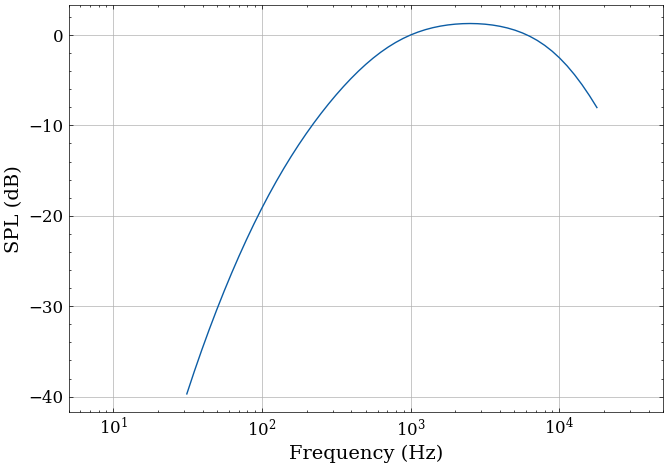

In [11]:
fig, ax = plt.subplots(figsize = (7,5))
ax.semilogx(centre_freqs, a_weight_sixth_octave(centre_freqs, np.zeros(len(centre_freqs))))

ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("SPL (dB)")
ax.grid()
ax.legend()
ax.set_xlim(5e0,5e4)

plt.tight_layout()
plt.savefig(r'C:\Users\angus\OneDrive\Documents\Cambridge\Year 4\Project\diagrams for final report\a_weighting.svg', bbox_inches='tight')
plt.show()

In [12]:
# Find matching STL stem
def broadband_from_index(index, remove_peaks = True):
    base_dir = ".."

    stl_file = None
    stl_dir  = os.path.join(base_dir, "stl_files")
    for f in os.listdir(stl_dir):
        if re.search(rf"DOE_{index}", f) and f.endswith(".stl"):
            stl_file = f[:-4]   # strip .stl
    if stl_file is None:
        raise ValueError(f"No STL file found for run {index}")
    # ── Audio  (kept for future audio tab) ──────────────────────────

    audio_path = os.path.join(base_dir, "audio", "doe_data_2", f"{stl_file}.wav")
    audio_data, sample_rate = None, None
    if os.path.exists(audio_path):
        try:
            audio_data, sample_rate = librosa.load(audio_path, sr=None)
        except Exception as e:
            print(f"  [audio] {stl_file}: {e}")
            
    nperseg = len(audio_data)//8
    noverlap = nperseg//2

    ## Plot ##
    frequencies, power = welch(
        audio_data,
        fs=sample_rate,
        window='blackman',
        nperseg=nperseg,
        noverlap=noverlap,
        scaling = 'spectrum'
        )

    amplitude = np.sqrt(power)
    amplitude_db = 20 * np.log10(amplitude + 1e-12)
    if remove_peaks:
        amplitude_db_peaks = medfilt(amplitude_db, kernel_size=19)  # kernel must be odd
        return frequencies, amplitude_db_peaks
    else:
        return frequencies, amplitude_db

In [13]:
def calculate_oaspl(amplitudes):
    return 10*np.log10(sum(np.power(10,amplitudes/10)))

OASPL (raw): -44.28376090465984
OASPL (peaks removed): -45.42155746357352


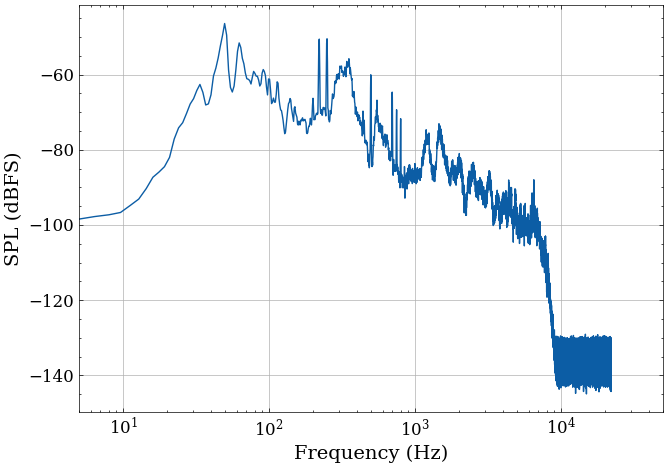

In [14]:
fig, ax = plt.subplots(figsize = (7,5))
freqs, amp_db = broadband_from_index(79, remove_peaks=False)
a_weighted_db = a_weight_sixth_octave(freqs, amp_db)
amplitude_db_peaks = medfilt(amp_db, kernel_size=19)
sixth_octave_band_levels_oaspl = calculate_oaspl(sixth_octave_spectrum_and_a_weight(freqs, amp_db)[1])
sixth_octave_band_levels_peaks_removed_oaspl = calculate_oaspl(sixth_octave_spectrum_and_a_weight(freqs, amplitude_db_peaks)[1])
print(f"OASPL (raw): {sixth_octave_band_levels_oaspl}")
print(f"OASPL (peaks removed): {sixth_octave_band_levels_peaks_removed_oaspl}")

ax.semilogx(freqs, amp_db)
# ax.semilogx(freqs, a_weighted_db)

ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("SPL (dBFS)")
ax.grid()
ax.legend()
ax.set_xlim(5e0,5e4)
# ax.set_xlim(1e0,1e1)

plt.tight_layout()
plt.savefig(r'C:\Users\angus\OneDrive\Documents\Cambridge\Year 4\Project\diagrams for final report\noise_raw.svg', bbox_inches='tight')
plt.show()

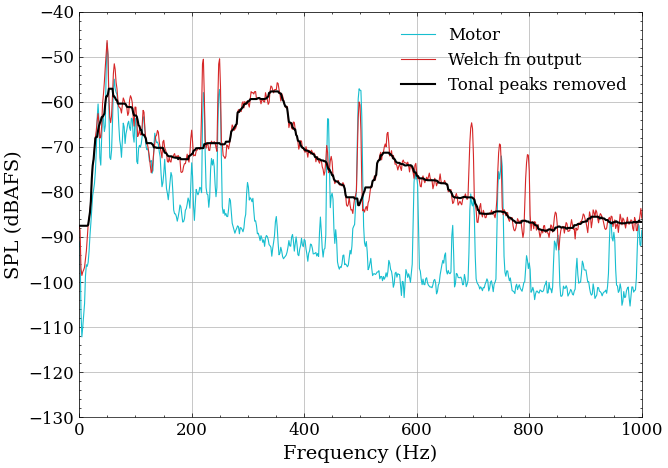

In [15]:
def extract_filename(index):
    stl_file = None
    for file in sorted(os.listdir(r"..\data\doe_data"), key=lambda f: int(re.search(r'\d+', f).group())):
        match = re.search(f"DOE_{index}", file)
        # print(file, match)
        if match:
            parts = file.split(sep=".")
            if parts[-1] == "csv":
                stl_file = file.rstrip(".csv")
                break
    if stl_file is None:
        raise ValueError("No file found")
    
    filename = os.path.join("..", "audio", "doe_data_2", f"{stl_file}.wav")
    # filename = f'..\audio\\doe_data_2\\{stl_file}.wav'
    return filename

def plot_frequency_spectrum():
    """
    Plot the frequency spectrum of audio data using FFT.
    
    Args:
        audio_path: Path to a .wav file (optional)
        sample_rate: Sample rate in Hz (used if generating test signal)
        duration: Duration in seconds (used if generating test signal)
    """
    
    # --- Plot ---
    fig, axes = plt.subplots(figsize=(7,5))
    
    # Calculate motor amplitude
    sample_rate, data = wavfile.read(r"..\audio\recording_motor_only_20260522_103803.wav")   
    nperseg = len(data)//8
    noverlap = nperseg//2
    
    frequencies, power = welch(
            data,
            fs=sample_rate,
            window='blackman',
            nperseg=nperseg,
            noverlap=noverlap,
            scaling = 'spectrum'
        )

    amplitude = np.sqrt(power) #- motor_amplitude
    amplitude_db = 20 * np.log10(amplitude + 1e-12)   

    axes.plot(frequencies, amplitude_db, linewidth=0.8, label=f'Motor', color=colours[9])
    
    for i in [79]:
        frequencies, amplitude_db = broadband_from_index(i, remove_peaks=False)
          
        axes.plot(frequencies, amplitude_db, linewidth=0.8, label=f'Welch fn output', color=colours[3])#, color=colours[i])
        
        amplitude_db = medfilt(amplitude_db, kernel_size=19)  # kernel must be odd
        
        axes.plot(frequencies, amplitude_db, linewidth=1.5, label=f'Tonal peaks removed', color='k')


    axes.set_xlabel("Frequency (Hz)")
    axes.set_ylabel("SPL (dBAFS)")
    axes.grid()
    axes.legend()
    axes.set_xlim(0,1000)
    # axes.set_xlim(000,6000)
    axes.set_ylim(-130,-40)

    plt.tight_layout()
    plt.savefig(r'C:\Users\angus\OneDrive\Documents\Cambridge\Year 4\Project\diagrams for final report\audio_input_smoothing.svg', bbox_inches='tight')
    plt.show()

    return

plot_frequency_spectrum()

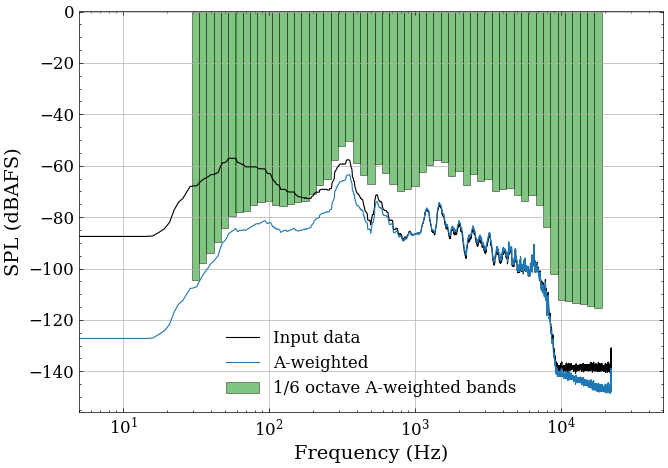

In [16]:
fig,ax = plt.subplots(figsize = (7,5))

for i in [79]:
       frequencies, amplitude_db_peaks = broadband_from_index(i)
       
       amplitude_a_weighted = a_weight_sixth_octave(frequencies, amplitude_db_peaks)
       centre_freqs, band_levels = sixth_octave_spectrum_and_a_weight(frequencies, amplitude_db_peaks)
       # Width of each bar as fraction of the band (in log space)
       widths = centre_freqs * (2**(1/12) - 2**(-1/12))  # actual band width in Hz
       ax.bar(centre_freqs, band_levels,  label='1/6 octave A-weighted bands', width=widths, 
              edgecolor='black', linewidth=0.5, alpha=0.6, zorder=0, color=colours[2])
       ax.semilogx(frequencies, amplitude_db_peaks, linewidth=0.8, label='Input data', color='k')
       ax.semilogx(frequencies, amplitude_a_weighted, linewidth=0.8, label='A-weighted', color=colours[0])
       # ax.semilogx(centre_freqs, band_levels, color = colours[i])
       # amplitude_a_weighted = a_weight_third_octave(frequencies, amplitude_db_peaks)
       # centre_freqs, band_levels = third_octave_spectrum_and_a_weight(frequencies, amplitude_db_peaks)
       # ax.semilogx(centre_freqs, band_levels, color = colours[i])

ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("SPL (dBAFS)")
ax.grid()
ax.legend()
ax.set_xlim(5e0,5e4)
# ax.set_xlim(1e2,5e3)
# ax.set_ylim(-80,-40)

plt.tight_layout()
plt.savefig(r'C:\Users\angus\OneDrive\Documents\Cambridge\Year 4\Project\diagrams for final report\audio_octave_weighted.svg', bbox_inches='tight')
plt.show()


In [17]:
def sixth_octave_bands_from_index(index):
    frequencies, amplitude_db_peaks = broadband_from_index(index, remove_peaks=True)
    # amplitude_a_weighted =  a_weight_sixth_octave(frequencies, amplitude_db_peaks)
    return sixth_octave_spectrum_and_a_weight(frequencies, amplitude_db_peaks)

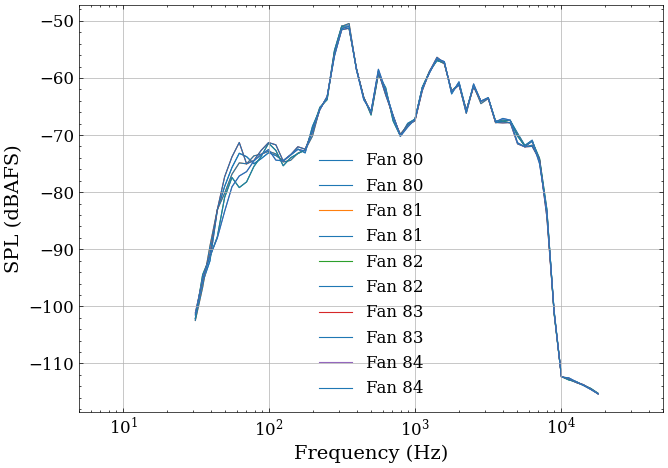

In [18]:
fig,ax = plt.subplots(figsize = (7,5))

for i in [80,81,82,83,84]:
       frequencies, amplitude_db_peaks = broadband_from_index(i)
       
       amplitude_a_weighted = a_weight_sixth_octave(frequencies, amplitude_db_peaks)
       centre_freqs, band_levels = sixth_octave_spectrum_and_a_weight(frequencies, amplitude_db_peaks)
       centre_freqs2, band_levels2 = sixth_octave_bands_from_index(i)
       # Width of each bar as fraction of the band (in log space)
       widths = centre_freqs * (2**(1/12) - 2**(-1/12))  # actual band width in Hz
       ax.semilogx(centre_freqs, band_levels,  label=f'Fan {i}', linewidth=0.8, zorder=0, color=colours[i%80])
       
       ax.semilogx(centre_freqs2, band_levels2,  label=f'Fan {i}', linewidth=0.8, zorder=0, color=colours[0])


ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("SPL (dBAFS)")
ax.grid()
ax.legend()
ax.set_xlim(5e0,5e4)
# ax.set_xlim(1e2,5e3)
# ax.set_ylim(-80,-40)

plt.tight_layout()
plt.savefig(r'C:\Users\angus\OneDrive\Documents\Cambridge\Year 4\Project\diagrams for final report\audio_octave_weighted_control.svg', bbox_inches='tight')
plt.show()

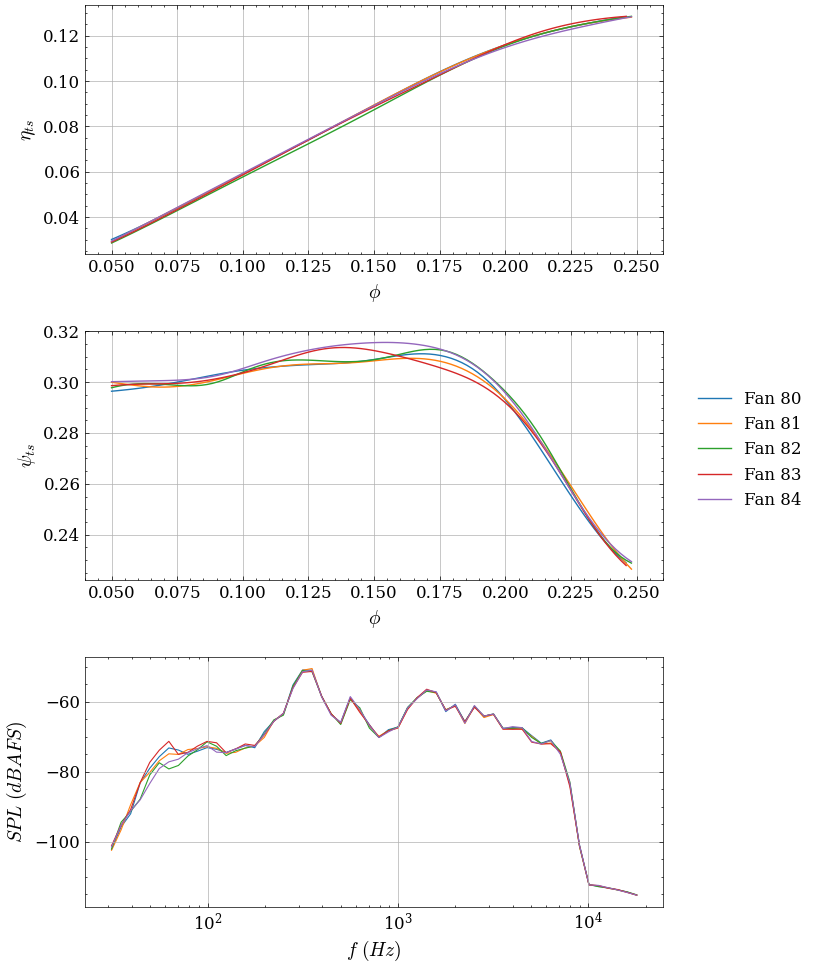

In [19]:
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(7, 10))
for j in [80,81,82,83,84]:
    # print(j)
    index = j
    psi, phi_end, eta = get_psi_eta_gp_with_end(index=index)
    mask = PHI_COMMON <= phi_end
    psi = psi[mask]
    eta = eta[mask]
    phi_plot = PHI_COMMON[mask]
    
    # ETA
    ax[0].plot(phi_plot, eta, color=colours[j%80], label=f'Fan {j}')
    ax[0].grid()
    ax[0].set_xlabel('$\phi$')
    ax[0].set_ylabel('$\eta_{ts}$')
    ax[0].set_xlim(0.04, 0.26)

    # PSI
    ax[1].plot(phi_plot, psi, color=colours[j%80])
    ax[1].grid()
    ax[1].set_xlabel('$\phi$')
    ax[1].set_ylabel('$\psi_{ts}$')
    ax[1].set_xlim(0.04, 0.26)

    # Audio

    frequencies, band_levels = sixth_octave_bands_from_index(j)

    ax[2].semilogx(frequencies, band_levels, linewidth=0.8, zorder=0, color=colours[j%80])
    ax[2].grid()
    ax[2].set_xlabel('$f \ (Hz)$')
    ax[2].set_ylabel('$SPL \ (dBAFS)$')
    # ax[2].set_ylim()


fig.legend(bbox_to_anchor=(1.01, 0.6), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.savefig(r'C:\Users\angus\OneDrive\Documents\Cambridge\Year 4\Project\diagrams for final report\control_chics.svg', bbox_inches='tight')
plt.show()

In [20]:
oaspls = []
for r in runs:
    frequencies, amplitude_db = r["audio_frequencies"], r["audio_amplitude"]
    f, a = sixth_octave_spectrum_and_a_weight(frequencies, amplitude_db)
    oaspls.append(calculate_oaspl(a))

In [21]:
print(oaspls[80],oaspls[81],oaspls[82], oaspls[83],oaspls[84])

-47.108739211637875 -47.20406486046258 -47.23952812905358 -47.28715962237044 -47.169015373036615


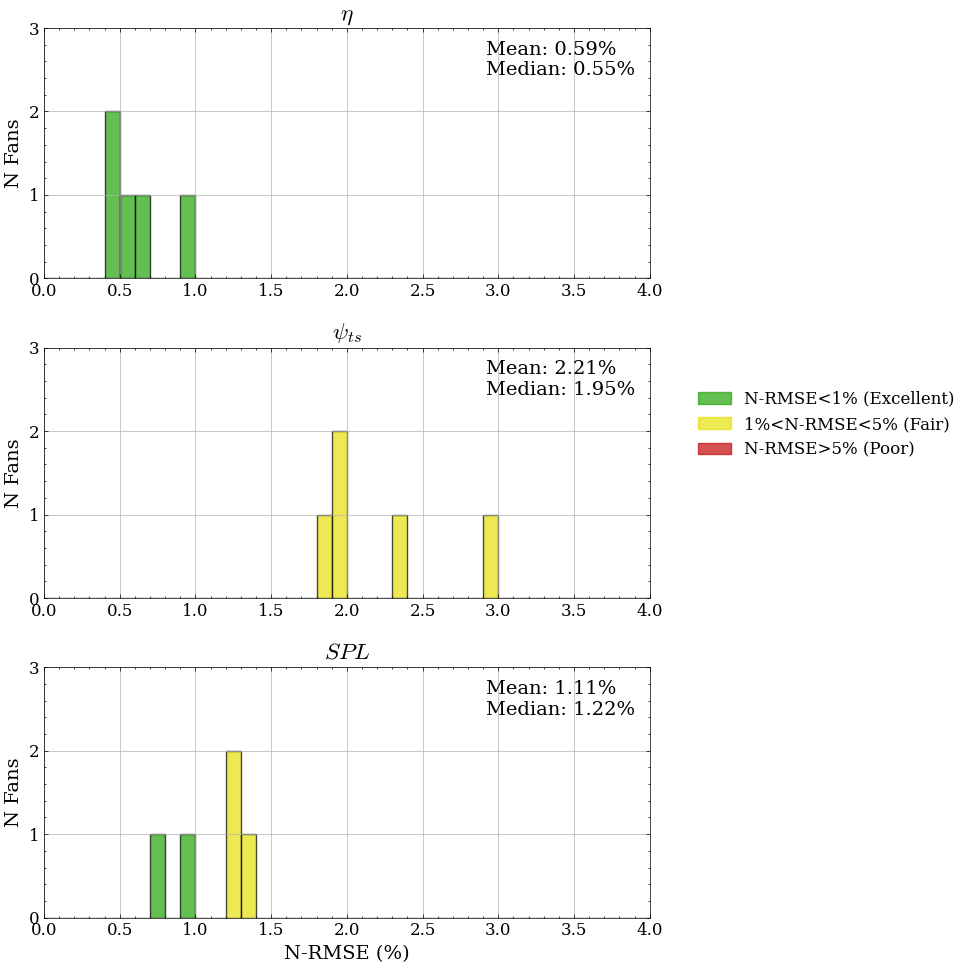

In [22]:
def get_nrmse_and_stats_control(X):
    X_reconstructed = np.mean(X, axis=0)
    # print(X_reconstructed)
    mins = [np.min(x) for x in X]
    maxs = [np.max(x) for x in X]
    
    rmse_per_run = np.array([
        np.sqrt(mean_squared_error(X[i], X_reconstructed))/(maxs[i]-mins[i]) for i in range(len(X))
    ])*100
    
    return rmse_per_run, np.mean(rmse_per_run), np.median(rmse_per_run)

fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(7, 10), sharex=False)

bin_width = 0.1
bins = np.arange(0, 5 + bin_width, bin_width)
excellent_val = 1
fair_val = 5
n_stds = 3


etas = []
psis = []
spls = []

for index in [80,81,82,83,84]:
    psi, phi_end, eta = get_psi_eta_gp_with_end(index=index)
    mask = PHI_COMMON <= phi_end
    psi = psi[mask]
    eta = eta[mask]
    frequencies, band_levels = sixth_octave_bands_from_index(index)
    etas.append(eta)
    psis.append(psi)
    spls.append(band_levels)

min_length = min(len(eta) for eta in etas)
etas = [eta[:min_length] for eta in etas]
psis = [psi[:min_length] for psi in psis]

# ETA
rmse_per_run_eta, mean_rmse_eta, median_rmse_eta = get_nrmse_and_stats_control(etas)
n, bins, patches = ax[0].hist(rmse_per_run_eta, bins=bins, density = False, edgecolor='black')
# ax[0].axvline(mean_rmse_eta+n_stds*np.std(rmse_per_run_eta), color='red', alpha=0.7, linestyle='--')
# ax[0].plot(range(len(rmse_per_run_eta)), rmse_per_run_eta, color=colours[2], marker='o')
ax[0].grid()
ax[0].set_ylabel('N Fans')
ax[0].set_title("$\eta$")
ax[0].set_xlim(0,4)
ax[0].set_ylim(0,3)
ax[0].text(0.73, 0.95, f'Mean: {mean_rmse_eta:.2f}% \nMedian: {median_rmse_eta:.2f}%',
        transform=ax[0].transAxes,  # 0-1 relative to axes
        ha='left', va='top')
ax[0].set_yticks([0,1,2,3])

# Color bars based on their index (position)
for i, patch in enumerate(patches):
    patch.set_alpha(0.7)
    if i < excellent_val/bin_width:
        patch.set_facecolor("#23a508")
    elif i < fair_val/bin_width:
        patch.set_facecolor("#e4e009")
    else:
        patch.set_facecolor("#c40808")

# PSI
rmse_per_run_psi, mean_rmse_psi, median_rmse_psi = get_nrmse_and_stats_control(psis)

n, bins, patches = ax[1].hist(rmse_per_run_psi, bins=bins, density = False, edgecolor='black')
# ax[1].axvline(mean_rmse_psi+n_stds*np.std(rmse_per_run_psi), color='red', alpha=0.7, linestyle='--')
ax[1].grid()
ax[1].set_ylabel('N Fans')
ax[1].set_title("$\psi_{ts}$")
ax[1].set_xlim(0,4)
ax[1].set_ylim(0,3)
ax[1].text(0.73, 0.95, f'Mean: {mean_rmse_psi:.2f}% \nMedian: {median_rmse_psi:.2f}%',
        transform=ax[1].transAxes,  # 0-1 relative to axes
        ha='left', va='top')
ax[1].set_yticks([0,1,2,3])

# Color bars based on their index (position)
for i, patch in enumerate(patches):
    patch.set_alpha(0.7)
    if i < excellent_val/bin_width:
        patch.set_facecolor("#23a508")
    elif i < fair_val/bin_width:
        patch.set_facecolor("#e4e009")
    else:
        patch.set_facecolor("#c40808")
        
# SPL
rmse_per_run, mean_rmse, median_rmse = get_nrmse_and_stats_control(spls)
n, bins, patches = ax[2].hist(rmse_per_run, bins=bins, density = False, edgecolor='black')
# ax[2].axvline(mean_rmse+n_stds*np.std(rmse_per_run), color='red', alpha=0.7, linestyle='--')
# ax[0].plot(range(len(rmse_per_run_eta)), rmse_per_run_eta, color=colours[2], marker='o')
ax[2].grid()
ax[2].set_ylabel('N Fans')
ax[2].set_xlabel('N-RMSE (%)')
ax[2].set_xlim(0,4)
ax[2].set_ylim(0,3)
ax[2].set_title("$SPL$")
ax[2].text(0.73, 0.95, f'Mean: {mean_rmse:.2f}% \nMedian: {median_rmse:.2f}%',
        transform=ax[2].transAxes,  # 0-1 relative to axes
        ha='left', va='top')
ax[2].set_yticks([0,1,2,3])

# Color bars based on their index (position)
for i, patch in enumerate(patches):
    patch.set_alpha(0.7)
    if i < excellent_val/bin_width:
        patch.set_facecolor("#23a508")
    elif i < fair_val/bin_width:
        patch.set_facecolor("#e4e009")
    else:
        patch.set_facecolor("#c40808")

# Legend
green_patch  = mpatches.Patch(color="#23a508", alpha = 0.7,  label=f'N-RMSE<{excellent_val}% (Excellent)')
yellow_patch = mpatches.Patch(color="#e4e009", alpha = 0.7, label=f'{excellent_val}%<N-RMSE<{fair_val}% (Fair)')
red_patch    = mpatches.Patch(color="#c40808", alpha = 0.7,    label=f'N-RMSE>{fair_val}% (Poor)')
# threshold_line = mlines.Line2D([], [], color='red', alpha=0.7, linestyle='--', label=f'$\mu+{n_stds}\sigma$')


fig.legend(handles=[green_patch, yellow_patch, red_patch], bbox_to_anchor=(1.01, 0.6), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.savefig(r'C:\Users\angus\OneDrive\Documents\Cambridge\Year 4\Project\diagrams for final report\control_RMSE.svg', bbox_inches='tight')
plt.show()

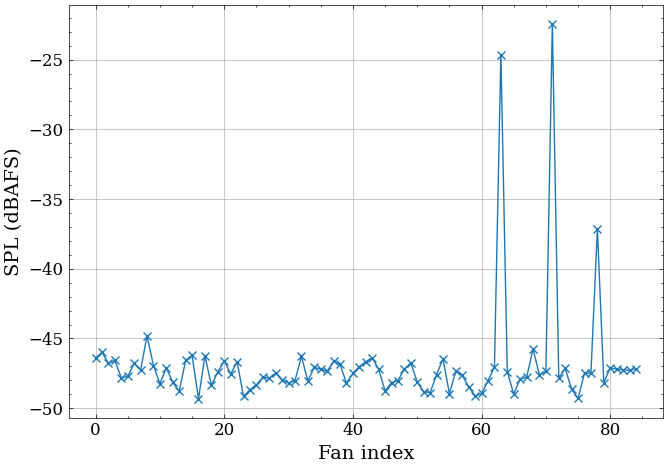

In [23]:
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(range(len(runs)), oaspls, color=colours[0], marker='x')
ax.grid()
ax.set_ylabel("SPL (dBAFS)")
ax.set_xlabel("Fan index")

plt.tight_layout()
plt.savefig(r'C:\Users\angus\OneDrive\Documents\Cambridge\Year 4\Project\diagrams for final report\oaspls.svg', bbox_inches='tight')
plt.show()

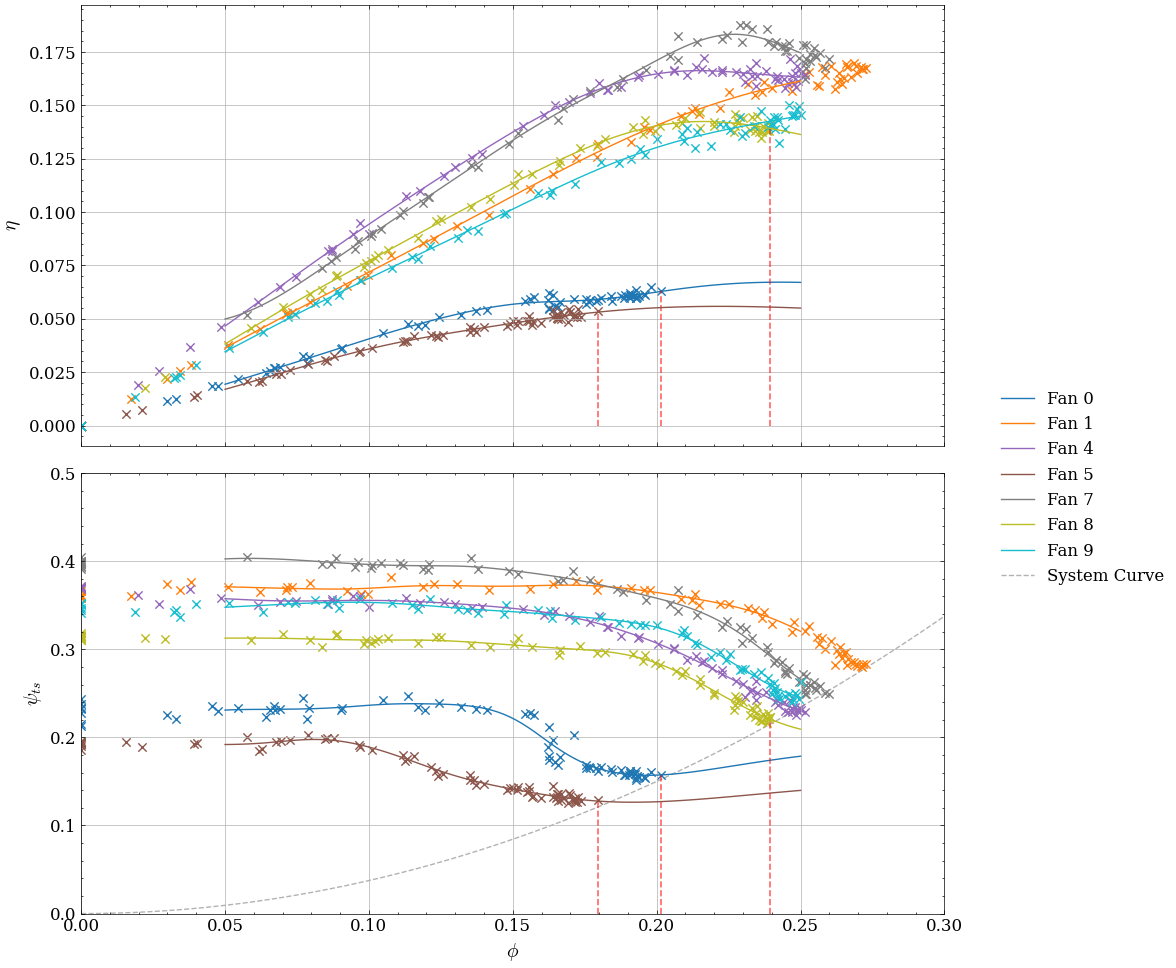

In [24]:
fig,ax = plt.subplots(2,1,figsize = (10,10),sharex=True)

for i in range(n_points):
    if i==2 or i==3 or i==6:
        continue
    psi_real,eta_real, phi_real = get_psi_eta_phi_real(i)
    psi, phi_end, eta = get_psi_eta_gp_with_end(i)
    
    # Psi Plot
    # Real data
    ax[1].scatter(phi_real, psi_real, color=colours[i], marker='x')
    #GP smoothed
    ax[1].plot(PHI_COMMON, psi, color=colours[i], label=f'Fan {i}')
    
        
    # Eta Plot
    # Real data
    ax[0].scatter(phi_real, eta_real, color=colours[i], marker='x')
    #GP smoothed
    ax[0].plot(PHI_COMMON, eta, color=colours[i])
    
    #End marker
    # Find the psi value on the GP curve at phi_end
    idx = np.searchsorted(PHI_COMMON, phi_end)
    if idx == 100:
        continue
    else:
        psi_at_end = psi[idx]
        eta_at_end = eta[idx]

        ax[1].plot(
            [phi_end, phi_end],
            [0, psi_at_end],          # from y=0 up to the curve
            color='red', linewidth=1.2, linestyle='--',alpha=0.6
        )
        ax[0].plot(
            [phi_end, phi_end],
            [0, eta_at_end],          # from y=0 up to the curve
            color='red', linewidth=1.2, linestyle='--',alpha=0.6
        )
        

ax[1].grid()
ax[0].grid()
sys_curve_x = np.linspace(0,0.30,50)
k=3.75
ax[1].plot(sys_curve_x,k*sys_curve_x**2,label='System Curve',linestyle='--',alpha=0.6,color='grey',zorder=0)
ax[1].set_xlabel('$\phi$')
ax[1].set_ylabel('$\psi_{ts}$')
ax[0].set_ylabel('$\eta$')
ax[1].set_ylim(0,0.5)
ax[1].set_xlim(0,0.3)
fig.legend(bbox_to_anchor=(1.01, 0.6), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.savefig(r'C:\Users\angus\OneDrive\Documents\Cambridge\Year 4\Project\diagrams for final report\gp_smoothing.svg', bbox_inches='tight')
plt.show()


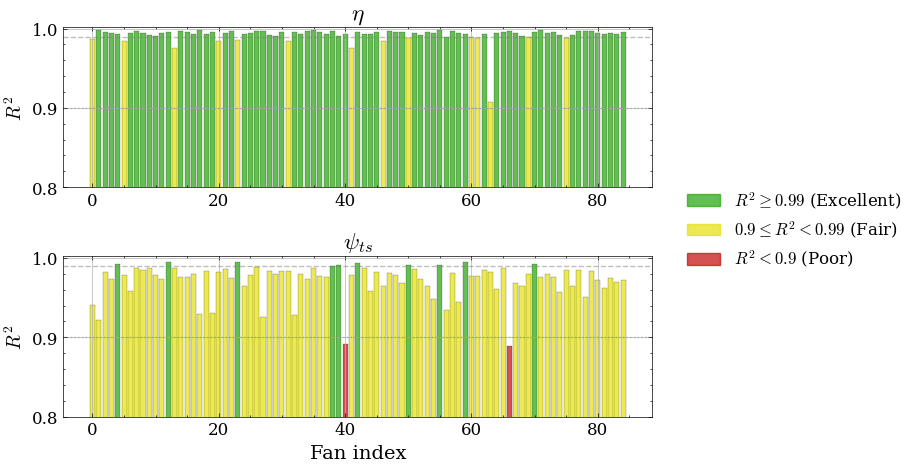

In [25]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(7, 5), sharex=False)
# cmap = cm.get_cmap('tab10')  # or 'viridis', 'plasma', 'hsv', etc.
# colours = [cmap(i / 10) for i in range(10)]
ylim_low = 0.8
ylim_high = 1.002

r2_colours = ["#23a508" if v >= 0.99 else "#e4e009" if v >= 0.90 else "#c40808" for v in r2s_eta]
ax[0].bar(range(len(r2s_eta)), r2s_eta, edgecolor='black', linewidth=0.2, color=r2_colours, alpha=0.7)
ax[0].axhline(0.99, color='grey', linestyle='--', alpha=0.5)
ax[0].axhline(0.90, color='grey', linestyle=':', alpha=0.5)
ax[0].set_ylabel('$R^2$')
ax[0].set_ylim(ylim_low,ylim_high)
ax[0].grid()
ax[0].set_title("$\eta$")

r2_colours = ["#23a508" if v >= 0.99 else "#e4e009" if v >= 0.90 else "#c40808" for v in r2s_psi]
ax[1].bar(range(len(r2s_psi)), r2s_psi, edgecolor='black', linewidth=0.2, color=r2_colours, alpha=0.7)
ax[1].axhline(0.99, color='grey', linestyle='--', alpha=0.5)
ax[1].axhline(0.90, color='grey', linestyle=':', alpha=0.5)
ax[1].set_xlabel('Fan index')
ax[1].set_ylabel('$R^2$')
ax[1].set_ylim(ylim_low,ylim_high)
ax[1].grid()
ax[1].set_title("$\psi_{ts}$")

# Legend
green_patch  = mpatches.Patch(color="#23a508", alpha = 0.7,  label='$R^2 \geq 0.99$ (Excellent)')
yellow_patch = mpatches.Patch(color="#e4e009", alpha = 0.7, label='$0.9 \leq R^2 < 0.99$ (Fair)')
red_patch    = mpatches.Patch(color="#c40808", alpha = 0.7,    label='$R^2 < 0.9$ (Poor)')


fig.legend(handles=[green_patch, yellow_patch, red_patch], bbox_to_anchor=(1.01, 0.6), loc='upper left', borderaxespad=0)
fig.tight_layout()
plt.savefig(r'C:\Users\angus\OneDrive\Documents\Cambridge\Year 4\Project\diagrams for final report\gp_smoothing_r2.svg', bbox_inches='tight')
plt.show()

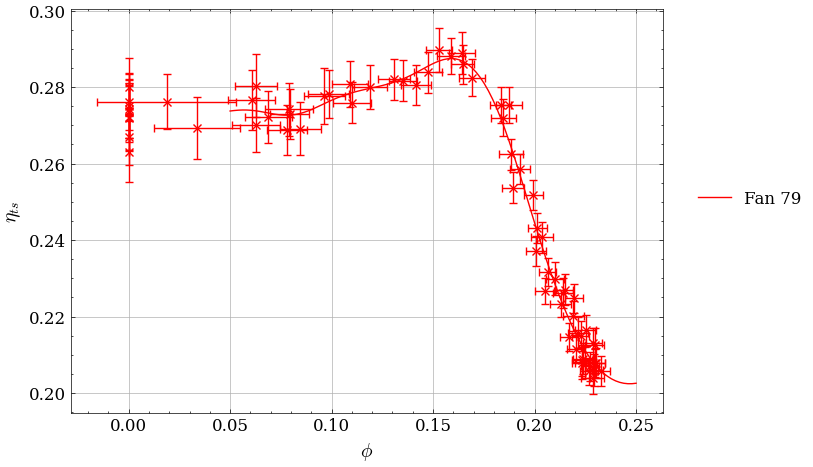

In [26]:
fig,ax = plt.subplots(figsize=(7,5))
i = 79
psi_real,eta_real, phi_real, phi_conf, psi_conf = get_psi_eta_phi_real(i, return_confidence=True)
psi, phi_end, eta = get_psi_eta_gp_with_end(i)

# Psi Plot
# Real data
ax.errorbar(phi_real, psi_real, xerr=phi_conf, yerr=psi_conf, color="red",fmt='x',capsize=3)
#GP smoothed
ax.plot(PHI_COMMON, psi, color="red", label=f'Fan {i}')
ax.grid()
# sys_curve_x = np.linspace(0,0.30,50)
# k=3.75
# ax.plot(sys_curve_x,k*sys_curve_x**2,label='System Curve',linestyle='--',alpha=0.6,color='grey',zorder=0)
ax.set_xlabel('$\phi$')
ax.set_ylabel('$\psi_{ts}$')
ax.set_ylabel('$\eta_{ts}$')
# ax.set_ylim(0,0.5)
# ax.set_xlim(0,0.3)
fig.legend(bbox_to_anchor=(1.01, 0.6), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

In [27]:
def remove_outliers_from_smoothing(runs, r2s):
    threshold = 0.9
    mask = np.array(r2s)>=threshold
    modified_runs = [r for r, m in zip(runs, mask) if m]
    return modified_runs

In [28]:
modified_runs_psi = remove_outliers_from_smoothing(runs, r2s_psi)
modified_runs_eta = remove_outliers_from_smoothing(runs, r2s_eta)

# PCA

In [29]:
PSI_PCA = PCAModel(modified_runs_psi, curve_key="psi", n_modes=5)
ETA_PCA = PCAModel(modified_runs_eta, curve_key="eta", n_modes=3)

In [30]:
def return_real_index_from_fan(pca, fan_index):
    try:
        idx = np.where(pca.fan_indices == fan_index)[0][0]
    except IndexError as e:
        print("[Index Error] Fan index has been outliered, try again. ", e)
        return None
    return idx

In [31]:
AUDIO_PCA = PCAModel(runs, "audio_amplitude",n_modes=6)

In [32]:
print(len(AUDIO_PCA.runs))
calculate_oaspl(AUDIO_PCA.runs[63]["audio_amplitude"])

85


np.float64(-24.922109158434886)

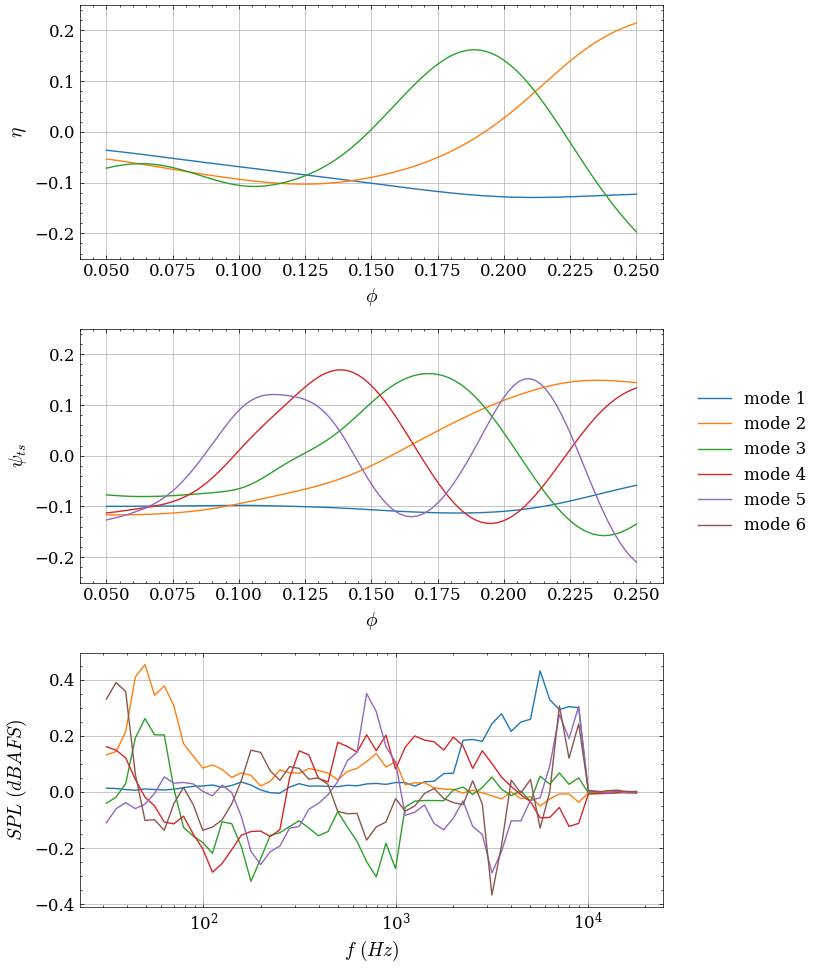

In [33]:
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(7, 10), sharex=False)
ylim_low = -0.25
ylim_high = 0.25

# ETA modes
for i, mode in enumerate(ETA_PCA.modes):
    ax[0].plot(PHI_COMMON, mode, color=colours[i])
ax[0].grid()
# ax[0].set_xlabel('$\phi$')
ax[0].set_ylabel('$\eta$')
ax[0].set_xlim(0.04, 0.26)
ax[0].set_xlabel('$\phi$')
ax[0].set_ylim(ylim_low,ylim_high)

# PSI modes
for i, mode in enumerate(PSI_PCA.modes):
    ax[1].plot(PHI_COMMON, mode, color=colours[i])
ax[1].grid()
ax[1].set_xlabel('$\phi$')
ax[1].set_ylabel('$\psi_{ts}$')
ax[1].set_xlim(0.04, 0.26)
ax[1].set_ylim(ylim_low,ylim_high)

# AUDIO modes
for i, mode in enumerate(AUDIO_PCA.modes):
    ax[2].semilogx(centre_freqs, mode, color=colours[i],  label=f'mode {i+1}')
ax[2].grid()
ax[2].set_xlabel('$f \ (Hz)$')
ax[2].set_ylabel('$SPL \ (dBAFS)$')

fig.legend(bbox_to_anchor=(1.01, 0.6), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.savefig(r'C:\Users\angus\OneDrive\Documents\Cambridge\Year 4\Project\diagrams for final report\pca_modes.svg', bbox_inches='tight')
plt.show()

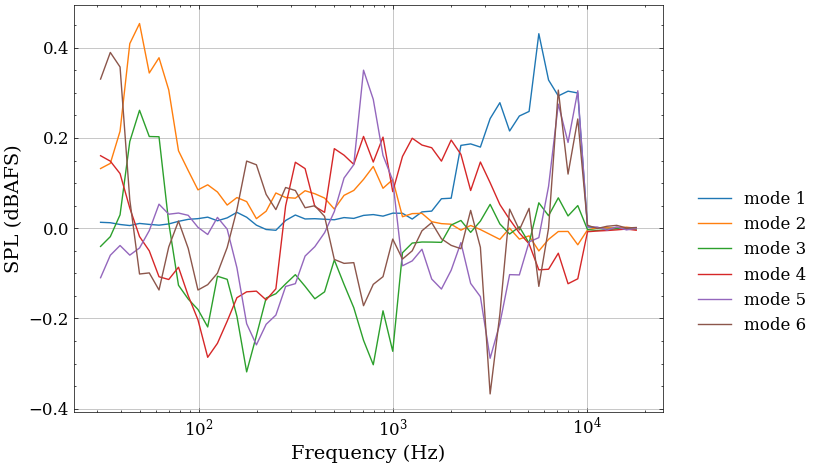

In [34]:
fig, ax = plt.subplots(figsize=(7, 5), sharex=True)
ylim_low = -0.25
ylim_high = 0.25

for i, mode in enumerate(AUDIO_PCA.modes):
    ax.semilogx(centre_freqs, mode, color=colours[i],  label=f'mode {i+1}')
ax.grid()
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('SPL (dBAFS)')

fig.legend(bbox_to_anchor=(1.01, 0.6), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.savefig(r'C:\Users\angus\OneDrive\Documents\Cambridge\Year 4\Project\diagrams for final report\audio_pca_modes.svg', bbox_inches='tight')
plt.show()

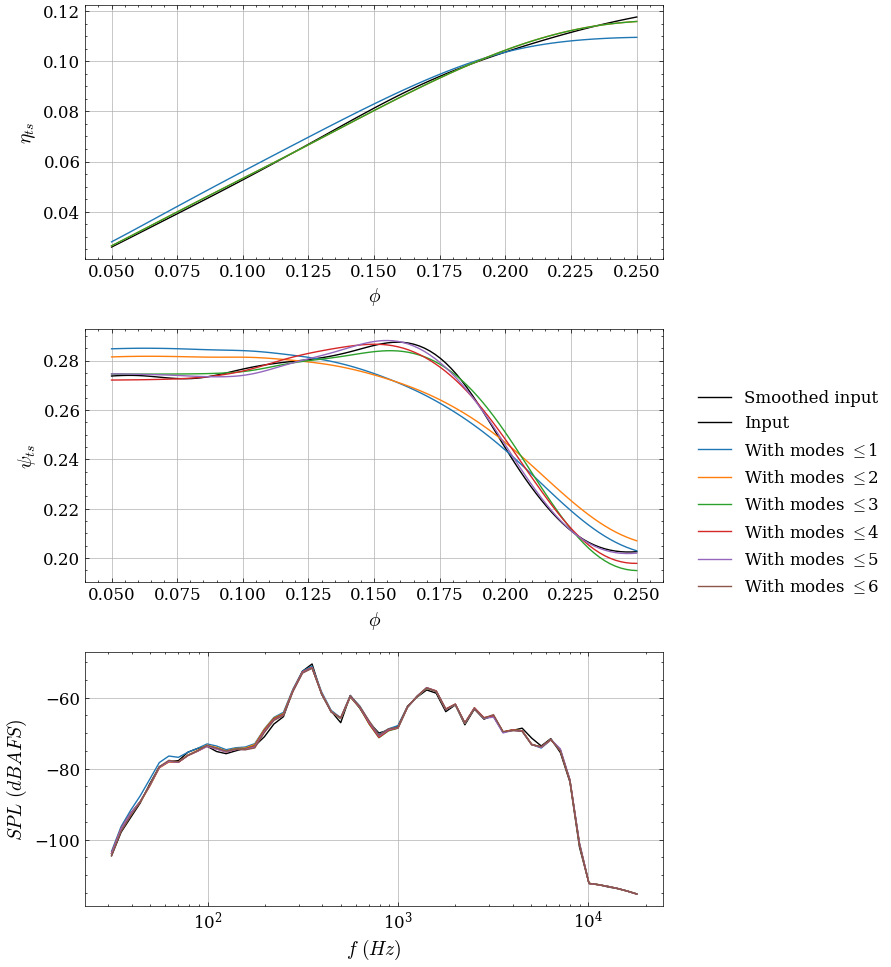

In [35]:
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(7, 10))
index = 79
psi, phi_end, eta = get_psi_eta_gp_with_end(index=index)

# ETA
scores_eta = ETA_PCA.scores[return_real_index_from_fan(ETA_PCA, index)]
modes_eta  = ETA_PCA.modes
mean_curve_eta = ETA_PCA.mean_curve

ax[0].plot(PHI_COMMON, eta, color='k', label='Smoothed input')
for i, mode in enumerate(modes_eta):
    active_modes  = modes_eta[:i+1]
    active_scores = scores_eta[:i+1]
    curve_with_active_modes = mean_curve_eta + active_scores @ active_modes
    ax[0].plot(PHI_COMMON, curve_with_active_modes, color=colours[i])
ax[0].grid()
ax[0].set_xlabel('$\phi$')
ax[0].set_ylabel('$\eta_{ts}$')
ax[0].set_xlim(0.04, 0.26)

# PSI
scores_psi = PSI_PCA.scores[return_real_index_from_fan(PSI_PCA, index)]
modes_psi  = PSI_PCA.modes
mean_curve_psi = PSI_PCA.mean_curve

ax[1].plot(PHI_COMMON, psi, color='k')
for i, mode in enumerate(modes_psi):
    active_modes  = modes_psi[:i+1]
    active_scores = scores_psi[:i+1]
    curve_with_active_modes = mean_curve_psi + active_scores @ active_modes
    ax[1].plot(PHI_COMMON, curve_with_active_modes, color=colours[i])


ax[1].grid()
ax[1].set_xlabel('$\phi$')
ax[1].set_ylabel('$\psi_{ts}$')
ax[1].set_xlim(0.04, 0.26)

# Audio

scores_audio = AUDIO_PCA.scores[return_real_index_from_fan(AUDIO_PCA, index)]
modes_audio  = AUDIO_PCA.modes
mean_curve_audio = AUDIO_PCA.mean_curve

centre_freqs, band_levels = sixth_octave_bands_from_index(index)

ax[2].semilogx(centre_freqs, band_levels, color='k', label='Input')
for i, mode in enumerate(modes_audio):
    active_modes  = modes_audio[:i+1]
    active_scores = scores_audio[:i+1]
    curve_with_active_modes = mean_curve_audio + active_scores @ active_modes
    ax[2].semilogx(centre_freqs, curve_with_active_modes, color=colours[i], label=f'With modes $\leq${i+1}')
    
# ax[2].set_xlim(100, 500)
ax[2].grid()
ax[2].set_xlabel('$f \ (Hz)$')
ax[2].set_ylabel('$SPL \ (dBAFS)$')


fig.legend(bbox_to_anchor=(1.01, 0.6), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.savefig(r'C:\Users\angus\OneDrive\Documents\Cambridge\Year 4\Project\diagrams for final report\pca_chics.svg', bbox_inches='tight')
plt.show()

[74.41704143776269, 84.32171559079745, 89.63388878750786, 92.06978752960912, 93.52610463761177, 94.68617240549929, 95.59252379164472, 96.3880229107829, 96.88511756608307, 97.23499997588397]


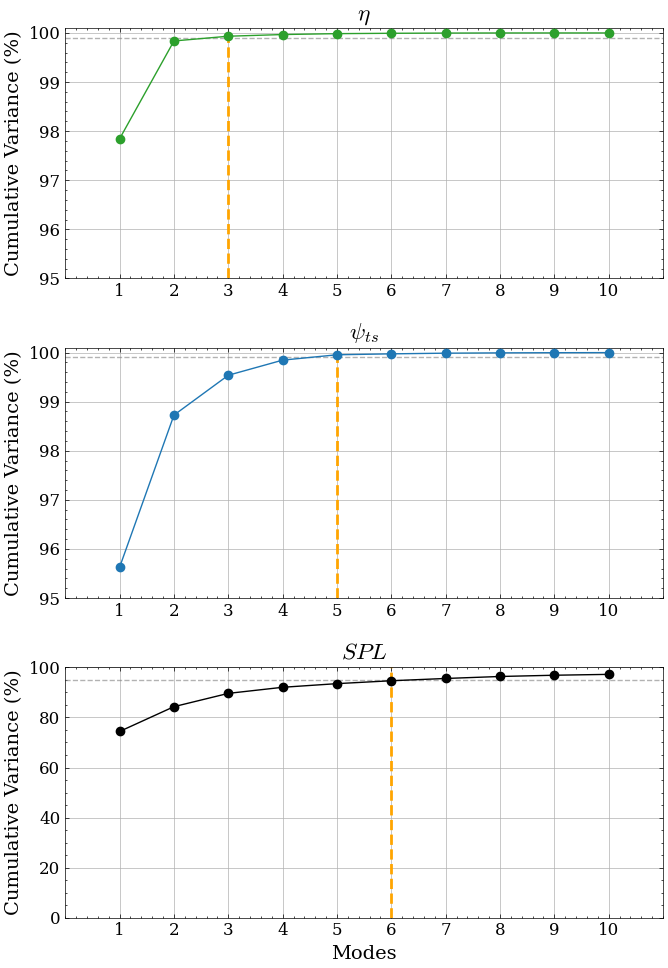

In [36]:
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(7, 10))

# ETA
k_max_eta   = min(len(ETA_PCA.singular_values), 10)
k_range_eta = list(range(1, k_max_eta + 1))
cum_var_eta = ETA_PCA.cum_var[:k_max_eta].tolist()

ax[0].plot(k_range_eta, cum_var_eta, color=colours[2], marker='o', zorder=3)
ax[0].grid()
ax[0].axhline(99.9, color='grey', linestyle='--', alpha=0.6)
ax[0].axvline(3, color='orange', linestyle='--', alpha=1, zorder=2, linewidth = 2)
ax[0].set_ylabel('Cumulative Variance (%)')
ax[0].set_xticks(range(1, 11))
ax[0].set_xlim(0.0, 11)
ax[0].set_ylim(95,100.1)
ax[0].set_title("$\eta$")


# PSI
k_max_psi   = min(len(PSI_PCA.singular_values), 10)
k_range_psi = list(range(1, k_max_psi + 1))
cum_var_psi = PSI_PCA.cum_var[:k_max_psi].tolist()

ax[1].plot(k_range_psi, cum_var_psi, color=colours[0], marker='o', zorder=3)
ax[1].grid()
ax[1].axhline(99.9, color='grey', linestyle='--', alpha=0.6)
ax[1].axvline(5, color='orange', linestyle='--', alpha=1, zorder=2, linewidth = 2)
ax[1].set_ylabel('Cumulative Variance (%)')
ax[1].set_xticks(range(1, 11))
ax[1].set_xlim(0.0, 11)
ax[1].set_ylim(95,100.1)
# ax[1].set_ylim(0,100.1)
ax[1].set_title("$\psi_{ts}$")

# Audio
k_max_audio   = min(len(AUDIO_PCA.singular_values), 10)
k_range_audio = list(range(1, k_max_audio + 1))
cum_var_audio = AUDIO_PCA.cum_var[:k_max_audio].tolist()

ax[2].plot(k_range_audio, cum_var_audio, color='k', marker='o', zorder=3)
ax[2].grid()
ax[2].axhline(95, color='grey', linestyle='--', alpha=0.6)
ax[2].axvline(6, color='orange', linestyle='--', alpha=1, zorder=2, linewidth = 2)
ax[2].set_ylabel('Cumulative Variance (%)')
ax[2].set_xlabel('Modes')
ax[2].set_xticks(range(1, 11,1))
ax[2].set_xlim(0.0, 11)
ax[2].set_ylim(0,100.1)
ax[2].set_title("$SPL$")
print(cum_var_audio)

plt.tight_layout()
plt.savefig(r'C:\Users\angus\OneDrive\Documents\Cambridge\Year 4\Project\diagrams for final report\pca_variance.svg', bbox_inches='tight')
plt.show()

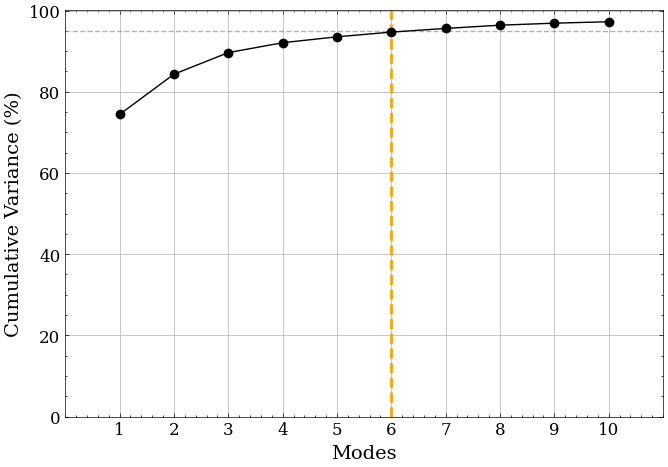

In [37]:
fig, ax = plt.subplots(figsize=(7, 5))

# ETA
k_max_audio   = min(len(AUDIO_PCA.singular_values), 10)
k_range_audio = list(range(1, k_max_audio + 1))
cum_var_audio = AUDIO_PCA.cum_var[:k_max_audio].tolist()

ax.plot(k_range_audio, cum_var_audio, color='k', marker='o', zorder=3)
ax.grid()
ax.axhline(95, color='grey', linestyle='--', alpha=0.6)
ax.axvline(6, color='orange', linestyle='--', alpha=1, zorder=2, linewidth = 2)
# ax.axhline(99, color='grey', linestyle='--', alpha=0.6)
# ax.axvline(6, color='orange', linestyle='--', alpha=1, zorder=2, linewidth = 2)
ax.set_ylabel('Cumulative Variance (%)')
ax.set_xlabel('Modes')
ax.set_xticks(range(1, 11,1))
ax.set_xlim(0.0, 11)
ax.set_ylim(0,100.1)
# ax.set_title("Frequencies")


plt.tight_layout()
plt.savefig(r'C:\Users\angus\OneDrive\Documents\Cambridge\Year 4\Project\diagrams for final report\audio_pca_variance.svg', bbox_inches='tight')
plt.show()

5.257938076703554


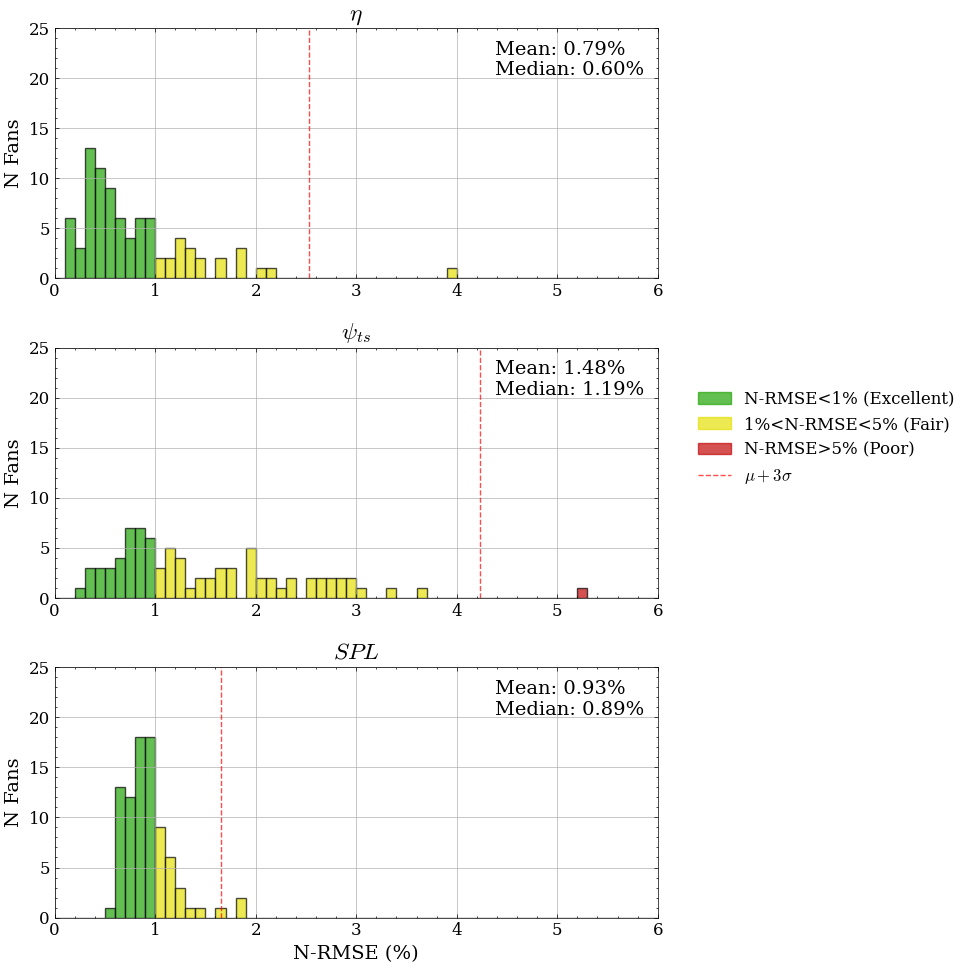

In [38]:
def get_nrmse_and_stats(pca):
    X = np.vstack([r[pca.curve_key] for r in pca.runs])
    X_reconstructed = pca.reconstruct(pca.scores)
    mins = [np.min(x) for x in X]
    maxs = [np.max(x) for x in X]
    
    rmse_per_run = np.array([
        np.sqrt(mean_squared_error(X[i], X_reconstructed[i]))/(maxs[i]-mins[i]) for i in range(len(pca.runs))
    ])*100
    
    return rmse_per_run, np.mean(rmse_per_run), np.median(rmse_per_run)

fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(7, 10), sharex=False)

bin_width = 0.1
bins = np.arange(0, 6 + bin_width, bin_width)
excellent_val = 1
fair_val = 5
n_stds = 3

# ETA
rmse_per_run_eta, mean_rmse_eta, median_rmse_eta = get_nrmse_and_stats(ETA_PCA)
n, bins, patches = ax[0].hist(rmse_per_run_eta, bins=bins, density = False, edgecolor='black')
ax[0].axvline(mean_rmse_eta+n_stds*np.std(rmse_per_run_eta), color='red', alpha=0.7, linestyle='--')
# ax[0].plot(range(len(rmse_per_run_eta)), rmse_per_run_eta, color=colours[2], marker='o')
ax[0].grid()
ax[0].set_ylabel('N Fans')
ax[0].set_title("$\eta$")
ax[0].set_xlim(0,6)
ax[0].set_ylim(0,25)
ax[0].text(0.73, 0.95, f'Mean: {mean_rmse_eta:.2f}% \nMedian: {median_rmse_eta:.2f}%',
        transform=ax[0].transAxes,  # 0-1 relative to axes
        ha='left', va='top')

# Color bars based on their index (position)
for i, patch in enumerate(patches):
    patch.set_alpha(0.7)
    if i < excellent_val/bin_width:
        patch.set_facecolor("#23a508")
    elif i < fair_val/bin_width:
        patch.set_facecolor("#e4e009")
    else:
        patch.set_facecolor("#c40808")

# PSI
rmse_per_run_psi, mean_rmse_psi, median_rmse_psi = get_nrmse_and_stats(PSI_PCA)
print(np.max(rmse_per_run_psi))

n, bins, patches = ax[1].hist(rmse_per_run_psi, bins=bins, density = False, edgecolor='black')
ax[1].axvline(mean_rmse_psi+n_stds*np.std(rmse_per_run_psi), color='red', alpha=0.7, linestyle='--')
ax[1].grid()
ax[1].set_ylabel('N Fans')
ax[1].set_title("$\psi_{ts}$")
ax[1].set_xlim(0,6)
ax[1].set_ylim(0,25)
ax[1].text(0.73, 0.95, f'Mean: {mean_rmse_psi:.2f}% \nMedian: {median_rmse_psi:.2f}%',
        transform=ax[1].transAxes,  # 0-1 relative to axes
        ha='left', va='top')

# Color bars based on their index (position)
for i, patch in enumerate(patches):
    patch.set_alpha(0.7)
    if i < excellent_val/bin_width:
        patch.set_facecolor("#23a508")
    elif i < fair_val/bin_width:
        patch.set_facecolor("#e4e009")
    else:
        patch.set_facecolor("#c40808")
        
# SPL
rmse_per_run, mean_rmse, median_rmse = get_nrmse_and_stats(AUDIO_PCA)
n, bins, patches = ax[2].hist(rmse_per_run, bins=bins, density = False, edgecolor='black')
ax[2].axvline(mean_rmse+n_stds*np.std(rmse_per_run), color='red', alpha=0.7, linestyle='--')
# ax[0].plot(range(len(rmse_per_run_eta)), rmse_per_run_eta, color=colours[2], marker='o')
ax[2].grid()
ax[2].set_ylabel('N Fans')
ax[2].set_xlabel('N-RMSE (%)')
ax[2].set_xlim(0,6)
ax[2].set_ylim(0,25)
ax[2].set_title("$SPL$")
ax[2].text(0.73, 0.95, f'Mean: {mean_rmse:.2f}% \nMedian: {median_rmse:.2f}%',
        transform=ax[2].transAxes,  # 0-1 relative to axes
        ha='left', va='top')

# Color bars based on their index (position)
for i, patch in enumerate(patches):
    patch.set_alpha(0.7)
    if i < excellent_val/bin_width:
        patch.set_facecolor("#23a508")
    elif i < fair_val/bin_width:
        patch.set_facecolor("#e4e009")
    else:
        patch.set_facecolor("#c40808")

# Legend
green_patch  = mpatches.Patch(color="#23a508", alpha = 0.7,  label=f'N-RMSE<{excellent_val}% (Excellent)')
yellow_patch = mpatches.Patch(color="#e4e009", alpha = 0.7, label=f'{excellent_val}%<N-RMSE<{fair_val}% (Fair)')
red_patch    = mpatches.Patch(color="#c40808", alpha = 0.7,    label=f'N-RMSE>{fair_val}% (Poor)')
threshold_line = mlines.Line2D([], [], color='red', alpha=0.7, linestyle='--', label=f'$\mu+{n_stds}\sigma$')


fig.legend(handles=[green_patch, yellow_patch, red_patch, threshold_line], bbox_to_anchor=(1.01, 0.6), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.savefig(r'C:\Users\angus\OneDrive\Documents\Cambridge\Year 4\Project\diagrams for final report\pca_RMSE.svg', bbox_inches='tight')
plt.show()

In [39]:
def remove_outliers_redo_PCA(pca):
    rmse_per_run, mean_rmse, median_rmse = get_nrmse_and_stats(pca)
    threshold = mean_rmse + n_stds*np.std(rmse_per_run)
    mask = rmse_per_run<threshold
    print([i for i, b in enumerate(mask) if b==False])
    runs = [r for r, m in zip(pca.runs, mask) if m]
    pca_new = PCAModel(runs, pca.curve_key, pca.n_modes)
    return pca_new

<!-- # GP Modelling -->

In [40]:
PSI_PCA_OUTLIER = remove_outliers_redo_PCA(PSI_PCA)
GP_PSI = GPSurrogates(PSI_PCA_OUTLIER)
ETA_PCA_OUTLIER = remove_outliers_redo_PCA(ETA_PCA)
GP_ETA = GPSurrogates(ETA_PCA_OUTLIER)

[27]
[GP] Fitted 5 surrogates on 82 runs.
[20]
[GP] Fitted 3 surrogates on 84 runs.


In [41]:
fan_index = 79
list_index_psi = return_real_index_from_fan(PSI_PCA_OUTLIER, fan_index)
list_index_eta = return_real_index_from_fan(ETA_PCA_OUTLIER, fan_index)

In [42]:
print(list_index_psi, list_index_eta)

76 78


In [43]:
m_psi, s_psi, s_m_psi, s_s_psi, e_m_psi, e_s_psi = GP_PSI.predict(PSI_PCA_OUTLIER.params[list_index_psi])
m_eta, s_eta, s_m_eta, s_s_eta, e_m_eta, e_s_eta = GP_ETA.predict(ETA_PCA_OUTLIER.params[list_index_eta])

In [44]:
AUDIO_PCA_OUTLIERED = remove_outliers_redo_PCA(AUDIO_PCA)
GP_AUDIO = GPSurrogates(AUDIO_PCA_OUTLIERED)

[23, 78]
[GP] Fitted 6 surrogates on 83 runs.


In [45]:
list_index_audio = return_real_index_from_fan(AUDIO_PCA_OUTLIERED, fan_index)
m_audio, s_audio = GP_AUDIO.predict(AUDIO_PCA_OUTLIERED.params[list_index_audio])

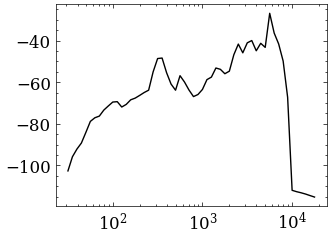

In [46]:
m, _ = GP_AUDIO.predict(AUDIO_PCA_OUTLIERED.params[return_real_index_from_fan(AUDIO_PCA_OUTLIERED, 63)])
curve = AUDIO_PCA_OUTLIERED.reconstruct(m)
plt.semilogx(centre_freqs, curve, color='k')

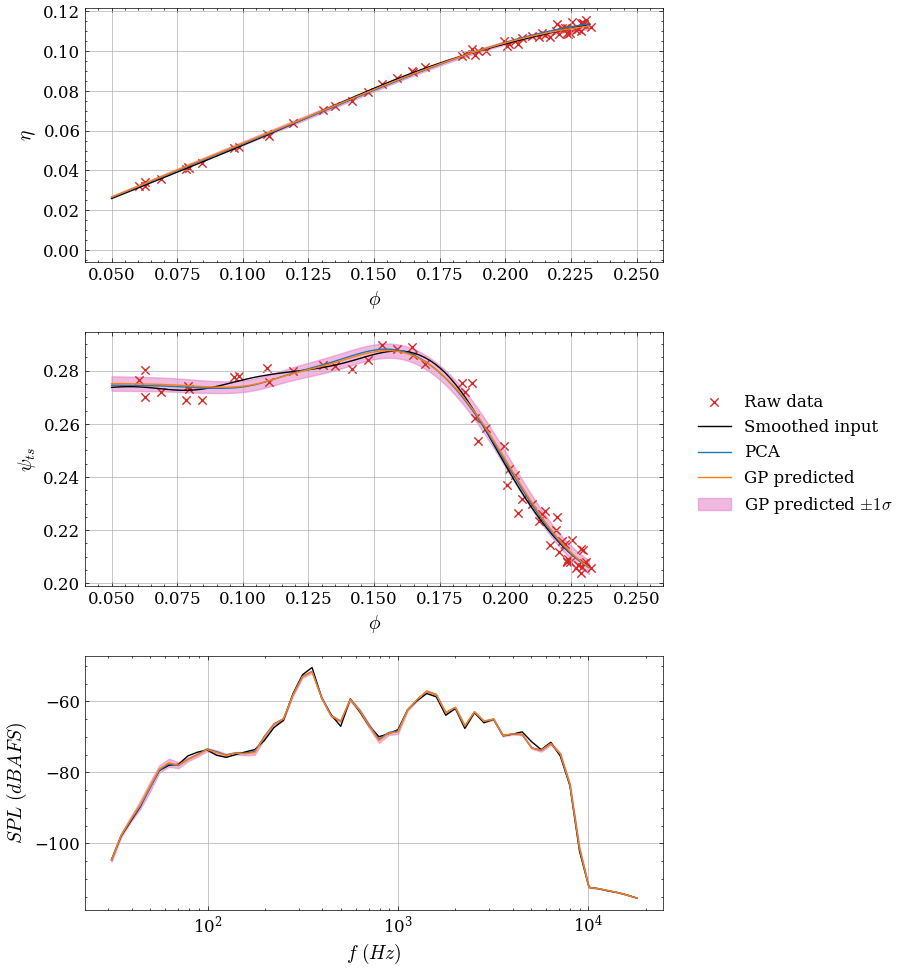

In [47]:
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(7, 10), sharex=False)

psi, phi_end, eta = get_psi_eta_gp_with_end(index=fan_index)
psi_real,eta_real, phi_real = get_psi_eta_phi_real(index=fan_index)

# ETA
smoothed_mask = PHI_COMMON < phi_end
mask = ETA_PCA_OUTLIER.return_mask(s_m_eta, e_m_eta)
scores_eta = ETA_PCA_OUTLIER.scores[list_index_eta]
modes_eta  = ETA_PCA_OUTLIER.modes[:,mask]
mean_curve_eta = ETA_PCA_OUTLIER.mean_curve[mask]

var       = sum((ETA_PCA_OUTLIER.modes[k] * s_eta[k]) ** 2 for k in range(ETA_PCA_OUTLIER.n_modes))
std       = np.sqrt(var)[mask]

ax[0].scatter(phi_real, eta_real, color=colours[3], marker='x', label='Raw data')
ax[0].plot(PHI_COMMON[smoothed_mask], eta[smoothed_mask], color='k', label='Smoothed input')
ax[0].plot(PHI_COMMON[mask], ETA_PCA_OUTLIER.reconstruct(scores_eta)[mask], color=colours[0], label=f'PCA')
ax[0].plot(PHI_COMMON[mask], ETA_PCA_OUTLIER.reconstruct(m_eta)[mask], color=colours[1], label=f'GP predicted')
ax[0].fill_between(PHI_COMMON[mask], ETA_PCA_OUTLIER.reconstruct(m_eta)[mask]-std, ETA_PCA_OUTLIER.reconstruct(m_eta)[mask]+std, color=colours[6], label=f'GP predicted $\pm1\sigma$', alpha=0.5, zorder=0)
ax[0].grid()
ax[0].set_xlabel('$\phi$')
ax[0].set_ylabel('$\eta$')
ax[0].set_xlim(0.04, 0.26)

# PSI
smoothed_mask = PHI_COMMON < phi_end
mask = PSI_PCA_OUTLIER.return_mask(s_m_psi, e_m_psi)
scores_psi = PSI_PCA_OUTLIER.scores[list_index_psi]
modes_psi  = PSI_PCA_OUTLIER.modes[:,mask]
mean_curve_psi = PSI_PCA_OUTLIER.mean_curve[mask]

var       = sum((PSI_PCA_OUTLIER.modes[k] * s_psi[k]) ** 2 for k in range(PSI_PCA_OUTLIER.n_modes))
std       = np.sqrt(var)[mask]

ax[1].scatter(phi_real, psi_real, color=colours[3], marker='x')
ax[1].plot(PHI_COMMON[smoothed_mask], psi[smoothed_mask], color='k')
ax[1].plot(PHI_COMMON[mask], PSI_PCA_OUTLIER.reconstruct(scores_psi)[mask], color=colours[0])
ax[1].plot(PHI_COMMON[mask], PSI_PCA_OUTLIER.reconstruct(m_psi)[mask], color=colours[1])
ax[1].fill_between(PHI_COMMON[mask], PSI_PCA_OUTLIER.reconstruct(m_psi)[mask]-std, PSI_PCA_OUTLIER.reconstruct(m_psi)[mask]+std, color=colours[6], alpha=0.5, zorder=0)
ax[1].grid()
ax[1].set_xlabel('$\phi$')
ax[1].set_ylabel('$\psi_{ts}$')
ax[1].set_xlim(0.04, 0.26)

# SPL
scores_audio = AUDIO_PCA_OUTLIERED.scores[return_real_index_from_fan(AUDIO_PCA_OUTLIERED, index)]
modes_audio  = AUDIO_PCA_OUTLIERED.modes
mean_curve_audio = AUDIO_PCA_OUTLIERED.mean_curve

var       = sum((AUDIO_PCA_OUTLIERED.modes[k] * s_audio[k]) ** 2 for k in range(AUDIO_PCA_OUTLIERED.n_modes))
std       = np.sqrt(var)

centre_freqs, band_levels = sixth_octave_bands_from_index(index)

ax[2].semilogx(centre_freqs, band_levels, color='k')
ax[2].semilogx(centre_freqs, AUDIO_PCA_OUTLIERED.reconstruct(scores_audio), color=colours[0])
ax[2].semilogx(centre_freqs, AUDIO_PCA_OUTLIERED.reconstruct(m_audio), color=colours[1])
ax[2].fill_between(centre_freqs, AUDIO_PCA_OUTLIERED.reconstruct(m_audio)-std, AUDIO_PCA_OUTLIERED.reconstruct(m_audio)+std, color=colours[6], alpha=0.5, zorder=0)
ax[2].grid()
ax[2].set_xlabel('$f \ (Hz)$')
ax[2].set_ylabel('$SPL \ (dBAFS)$')


fig.legend(bbox_to_anchor=(1.01, 0.6), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.savefig(r'C:\Users\angus\OneDrive\Documents\Cambridge\Year 4\Project\diagrams for final report\gp_chics_comparison.svg', bbox_inches='tight')
plt.show()

84
82
83


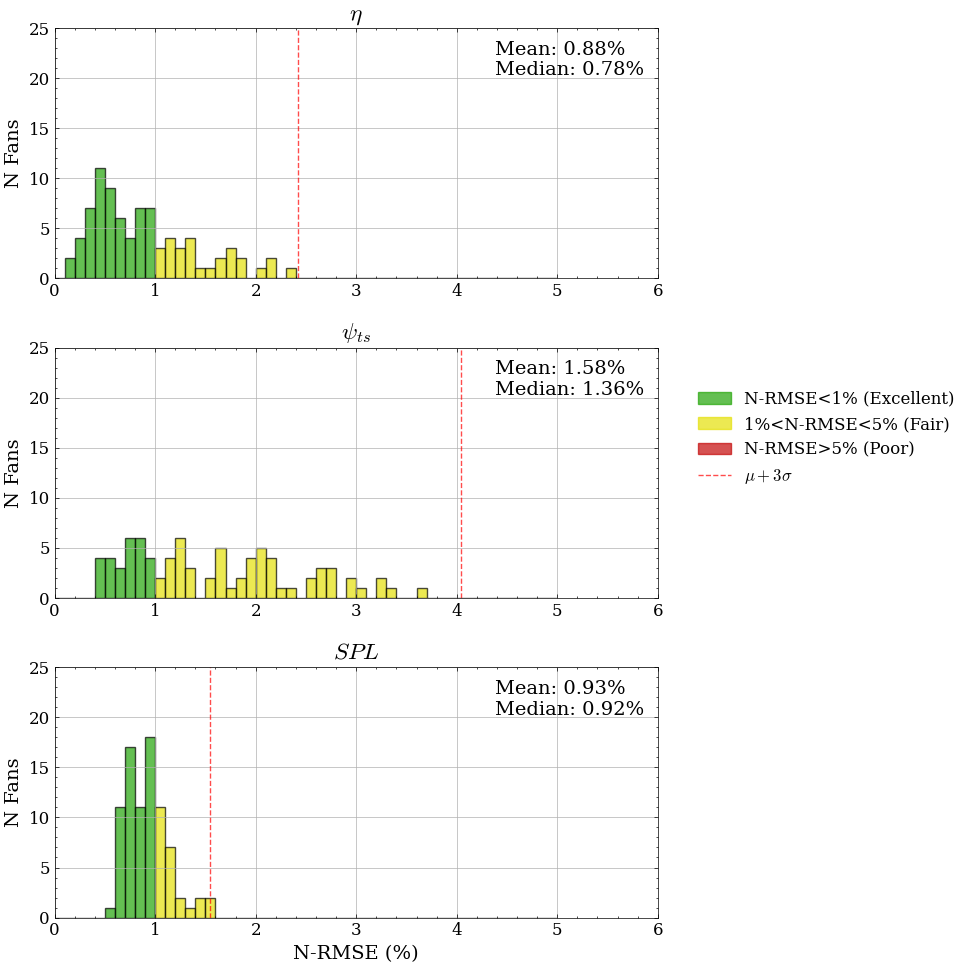

In [48]:
def get_nrmse_and_stats_with_gp(pca, gp, audio=False):
    X = np.vstack([r[pca.curve_key] for r in pca.runs])
    X_reconstructed = []
    print(len(pca.params))
    for p in pca.params:
        if audio:
            m, _ = gp.predict(p)
        else:
            m, _,_,_,_,_ = gp.predict(p)
        X_reconstructed.append(pca.reconstruct(m))
    mins = np.array([np.min(x) for x in X])
    maxs = np.array([np.max(x) for x in X])
    maxs_mins = maxs-mins
    # print(max(maxs_mins))
    
    rmse_per_run = np.array([
        np.sqrt(mean_squared_error(X[i], X_reconstructed[i]))/(maxs[i]-mins[i]) for i in range(len(pca.runs))
    ])*100
    
    return rmse_per_run, np.mean(rmse_per_run), np.median(rmse_per_run)

fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(7, 10), sharex=False)

bin_width = 0.1
bins = np.arange(0, 5 + bin_width, bin_width)
excellent_val = 1
fair_val = 5
n_stds = 3

# ETA
rmse_per_run_eta, mean_rmse_eta, median_rmse_eta = get_nrmse_and_stats_with_gp(ETA_PCA_OUTLIER, GP_ETA)
n, bins, patches = ax[0].hist(rmse_per_run_eta, bins=bins, density = False, edgecolor='black')
ax[0].axvline(mean_rmse_eta+n_stds*np.std(rmse_per_run_eta), color='red', alpha=0.7, linestyle='--')
ax[0].grid()
ax[0].set_ylabel('N Fans')
ax[0].set_title("$\eta$")
ax[0].set_xlim(0,6)
ax[0].set_ylim(0,25)
ax[0].text(0.73, 0.95, f'Mean: {mean_rmse_eta:.2f}% \nMedian: {median_rmse_eta:.2f}%',
        transform=ax[0].transAxes,  # 0-1 relative to axes
        ha='left', va='top')

# Color bars based on their index (position)
for i, patch in enumerate(patches):
    patch.set_alpha(0.7)
    if i < excellent_val/bin_width:
        patch.set_facecolor("#23a508")
    elif i < fair_val/bin_width:
        patch.set_facecolor("#e4e009")
    else:
        patch.set_facecolor("#c40808")

# PSI
rmse_per_run_psi, mean_rmse_psi, median_rmse_psi = get_nrmse_and_stats_with_gp(PSI_PCA_OUTLIER, GP_PSI)

n, bins, patches = ax[1].hist(rmse_per_run_psi, bins=bins, density = False, edgecolor='black')
ax[1].axvline(mean_rmse_psi+n_stds*np.std(rmse_per_run_psi), color='red', alpha=0.7, linestyle='--')
ax[1].grid()
ax[1].set_ylabel('N Fans')
ax[1].set_title("$\psi_{ts}$")
ax[1].set_xlim(0,6)
ax[1].set_ylim(0,25)
ax[1].text(0.73, 0.95, f'Mean: {mean_rmse_psi:.2f}% \nMedian: {median_rmse_psi:.2f}%',
        transform=ax[1].transAxes,  # 0-1 relative to axes
        ha='left', va='top')

# Color bars based on their index (position)
for i, patch in enumerate(patches):
    patch.set_alpha(0.7)
    if i < excellent_val/bin_width:
        patch.set_facecolor("#23a508")
    elif i < fair_val/bin_width:
        patch.set_facecolor("#e4e009")
    else:
        patch.set_facecolor("#c40808")

# SPL     
rmse_per_run, mean_rmse, median_rmse = get_nrmse_and_stats_with_gp(AUDIO_PCA_OUTLIERED, GP_AUDIO, audio=True)
n, bins, patches = ax[2].hist(rmse_per_run, bins=bins, density = False, edgecolor='black')
ax[2].axvline(mean_rmse+n_stds*np.std(rmse_per_run), color='red', alpha=0.7, linestyle='--')
ax[2].grid()
ax[2].set_ylabel('N Fans')
ax[2].set_xlabel('N-RMSE (%)')
ax[2].set_xlim(0,6)
ax[2].set_ylim(0,25)
ax[2].set_title("$SPL$")
ax[2].text(0.73, 0.95, f'Mean: {mean_rmse:.2f}% \nMedian: {median_rmse:.2f}%',
        transform=ax[2].transAxes,  # 0-1 relative to axes
        ha='left', va='top')

# Color bars based on their index (position)
for i, patch in enumerate(patches):
    patch.set_alpha(0.7)
    if i < excellent_val/bin_width:
        patch.set_facecolor("#23a508")
    elif i < fair_val/bin_width:
        patch.set_facecolor("#e4e009")
    else:
        patch.set_facecolor("#c40808")

# Legend
green_patch  = mpatches.Patch(color="#23a508", alpha = 0.7,  label=f'N-RMSE<{excellent_val}% (Excellent)')
yellow_patch = mpatches.Patch(color="#e4e009", alpha = 0.7, label=f'{excellent_val}%<N-RMSE<{fair_val}% (Fair)')
red_patch    = mpatches.Patch(color="#c40808", alpha = 0.7,    label=f'N-RMSE>{fair_val}% (Poor)')
threshold_line = mlines.Line2D([], [], color='red', alpha=0.7, linestyle='--', label=f'$\mu+{n_stds}\sigma$')


fig.legend(handles=[green_patch, yellow_patch, red_patch, threshold_line], bbox_to_anchor=(1.01, 0.6), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.savefig(r'C:\Users\angus\OneDrive\Documents\Cambridge\Year 4\Project\diagrams for final report\gp_RMSE.svg', bbox_inches='tight')
plt.show()

In [49]:
from pca_core import CENTRE_FREQS

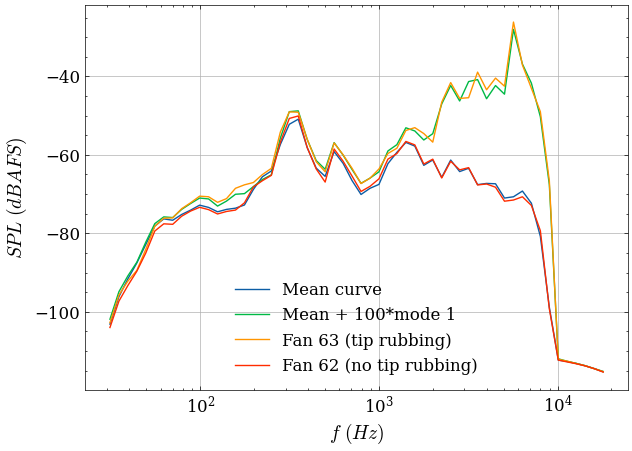

In [50]:
high_index = return_real_index_from_fan(AUDIO_PCA_OUTLIERED, 63)
low_index = return_real_index_from_fan(AUDIO_PCA_OUTLIERED, 62)
high_second_mode_index = return_real_index_from_fan(AUDIO_PCA_OUTLIERED, 22)
high_second_mode_index_2 = return_real_index_from_fan(AUDIO_PCA_OUTLIERED, 18)

modes = AUDIO_PCA_OUTLIERED.modes
n_curve_high = AUDIO_PCA_OUTLIERED.runs[high_index]["audio_amplitude"]
n_curve_low = AUDIO_PCA_OUTLIERED.runs[low_index]["audio_amplitude"]
high_second_mode_curve = AUDIO_PCA_OUTLIERED.runs[high_second_mode_index]["audio_amplitude"]
high_second_mode_curve_2 = AUDIO_PCA_OUTLIERED.runs[high_second_mode_index_2]["audio_amplitude"]
mean_curve = AUDIO_PCA_OUTLIERED.mean_curve

high_scores =  AUDIO_PCA_OUTLIERED.scores[high_index]
low_scores =  AUDIO_PCA_OUTLIERED.scores[low_index]

fig, ax = plt.subplots(figsize=(7,5))
ax.semilogx(CENTRE_FREQS,mean_curve, label='Mean curve')
ax.semilogx(CENTRE_FREQS,mean_curve+100*modes[0], label='Mean + 100*mode 1')
ax.semilogx(CENTRE_FREQS,n_curve_high, label=f'Fan 63 (tip rubbing)')
ax.semilogx(CENTRE_FREQS,n_curve_low, label=f'Fan 62 (no tip rubbing)')
# ax.semilogx(CENTRE_FREQS,high_second_mode_curve, label='Fan 22')
# ax.semilogx(CENTRE_FREQS,high_second_mode_curve_2, label='Fan 18')

# ax.semilogx(CENTRE_FREQS,mean_curve+100*modes[1], label='100x mode 2')

ax.grid()
ax.set_xlabel('$f \ (Hz)$')
ax.set_ylabel('$SPL \ (dBAFS)$')

ax.legend()

plt.tight_layout
plt.savefig(r'C:\Users\angus\OneDrive\Documents\Cambridge\Year 4\Project\diagrams for final report\audio_mode_shape_1.svg', bbox_inches='tight')
plt.show()

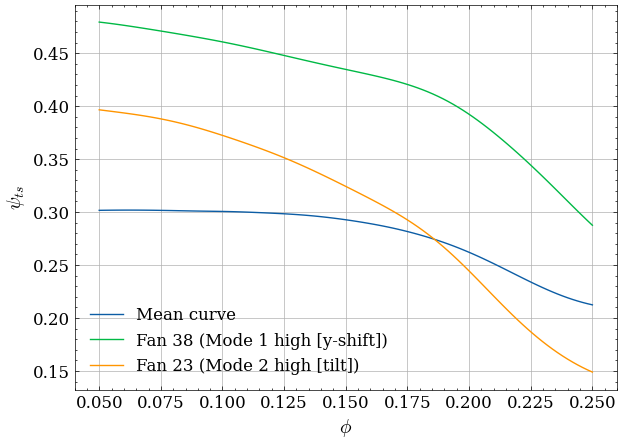

In [51]:
high_index = return_real_index_from_fan(PSI_PCA_OUTLIER, 38)
low_index = return_real_index_from_fan(PSI_PCA_OUTLIER, 23)
high_second_mode_index = return_real_index_from_fan(PSI_PCA_OUTLIER, 23)
high_second_mode_index_2 = return_real_index_from_fan(PSI_PCA_OUTLIER, 18)

modes = PSI_PCA_OUTLIER.modes
n_curve_high = PSI_PCA_OUTLIER.runs[high_index]["psi"]
mask_curve_high = PHI_COMMON < PSI_PCA_OUTLIER.runs[high_index]["phi_end"]
n_curve_low = PSI_PCA_OUTLIER.runs[low_index]["psi"]
high_second_mode_curve = PSI_PCA_OUTLIER.runs[high_second_mode_index]["psi"]
mask_curve_high_second = PHI_COMMON < PSI_PCA_OUTLIER.runs[high_second_mode_index]["phi_end"]
high_second_mode_curve_2 = PSI_PCA_OUTLIER.runs[high_second_mode_index_2]["psi"]
mean_curve = PSI_PCA_OUTLIER.mean_curve

high_scores =  PSI_PCA_OUTLIER.scores[high_index]
low_scores =  PSI_PCA_OUTLIER.scores[low_index]

fig, ax = plt.subplots(figsize=(7,5))
ax.plot(PHI_COMMON, mean_curve, label='Mean curve')
# ax.plot(PHI_COMMON,mean_curve+100*modes[0], label='Mean + 100*mode 1')
ax.plot(PHI_COMMON,n_curve_high, label=f'Fan 38 (Mode 1 high [y-shift])')
ax.plot(PHI_COMMON,high_second_mode_curve, label=f'Fan 23 (Mode 2 high [tilt])')
# ax.semilogx(CENTRE_FREQS,n_curve_low, label=f'Fan 62')
# ax.semilogx(CENTRE_FREQS,high_second_mode_curve, label='Fan 22')
# ax.semilogx(CENTRE_FREQS,high_second_mode_curve_2, label='Fan 18')

# ax.semilogx(CENTRE_FREQS,mean_curve+100*modes[1], label='100x mode 2')

ax.grid()

ax.set_xlabel('$\phi$')
ax.set_ylabel('$\psi_{ts}$')
ax.legend()

plt.tight_layout
plt.savefig(r'C:\Users\angus\OneDrive\Documents\Cambridge\Year 4\Project\diagrams for final report\mode_shapes_1_2.svg', bbox_inches='tight')
plt.show()

In [52]:
print(len(PSI_PCA_OUTLIER.scores))

82


In [53]:
print(np.argmax(np.abs(PSI_PCA_OUTLIER.scores[:,1])))
print(np.max(np.abs(PSI_PCA_OUTLIER.scores[:,1])))
print(return_real_index_from_fan(PSI_PCA_OUTLIER, 23))

23
0.49081196179119324
23


## Inverse Design

In [54]:
mm_h2o = 2.37
vol_flowrate = 55.5/3600 #m3/s

rho = 1.23
U = 3000*2*np.pi/60 * 0.0275
area= np.pi*(0.04**2-0.015**2)

ts_prise = mm_h2o*9.81*(1000/1000)
m_flowrate = vol_flowrate*rho

In [55]:
print(f"Total to static pressure rise coefficient (max): {(ts_prise/(rho*U**2)):.2f}; Flow coefficient (max): {vol_flowrate/area/U:.3f}")

Total to static pressure rise coefficient (max): 0.25; Flow coefficient (max): 0.413


In [56]:
def generate_axes_crossing(x,y):
    # Assuming all curves are in 1st quadrant and slope at either end of curve will intersect axes
    n_points = 20
    m, c, r, p, se = stats.linregress(x[:n_points], y[:n_points])
    y_crossing = c
    
    m, c, r, p, se = stats.linregress(x[-n_points:], y[-n_points:])
    
    x_crossing = -c/m
    
    return y_crossing, x_crossing
    

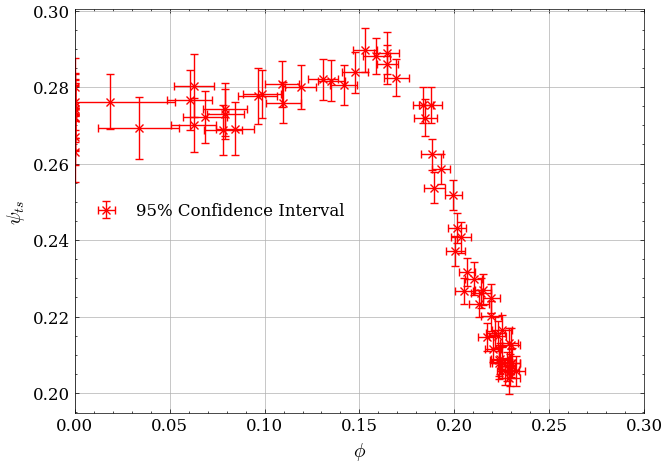

In [57]:
fig,ax = plt.subplots(figsize=(7,5))
i = 79
psi_real,eta_real, phi_real, phi_conf, psi_conf = get_psi_eta_phi_real(i, return_confidence=True)
psi, phi_end, eta = get_psi_eta_gp_with_end(i)
mask = PHI_COMMON<phi_end
# print(generate_axes_crossing(PHI_COMMON[mask], psi[mask]), PHI_COMMON[mask][-n_points:])
n_points = 20
# m, c, r, p, se = stats.linregress(PHI_COMMON[mask][-n_points:], psi[mask][-n_points:])
# coeffs = np.polyfit(PHI_COMMON[mask][:20], psi[mask][:20], 1)  # just change 1 to 2
# a, b = coeffs
x = np.linspace(0,0.8,50)
# ax.plot(x,m*x+c)

# Psi Plot
# Real data
ax.errorbar(phi_real, psi_real, xerr=phi_conf, yerr=psi_conf, color="red",fmt='x',capsize=3, label="95% Confidence Interval")
#GP smoothed
# ax.plot(PHI_COMMON[mask], psi[mask], color="red", label=f'Fan {i}')

ax.grid()
# sys_curve_x = np.linspace(0,0.30,50)
# k=3.75
# ax.plot(sys_curve_x,k*sys_curve_x**2,label='System Curve',linestyle='--',alpha=0.6,color='grey',zorder=0)
ax.set_xlabel('$\phi$')
ax.set_ylabel('$\psi_{ts}$')
# ax.set_ylabel('$\eta_{ts}$')
# ax.set_ylim(0,0.5)
ax.set_xlim(0,0.3)
ax.legend(loc='center left')
# fig.legend(bbox_to_anchor=(1.01, 0.6), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.savefig(f'C:\\Users\\angus\\OneDrive\\Documents\\Cambridge\\Year 4\\Project\\diagrams for final report\\characteristic_confidence_interval.svg', bbox_inches='tight')
plt.show()

# Model Output

In [58]:
from pca_core import PARAM_LO, PARAM_HI, PARAM_DEFAULTS, CENTRE_FREQS, PHI_COMMON, axes_crossing, calculate_oaspl

In [59]:
def get_curve_from_params(pca, gp, params):
    if pca.curve_key == "audio_amplitude":
        pred, std = gp.predict(params)
        return CENTRE_FREQS, pca.reconstruct(pred)
    else:
        pred, std, _, _, phi_end, _ = gp.predict(params)
        mask = PHI_COMMON < phi_end
        curve = pca.reconstruct(pred)[mask]
        return PHI_COMMON[mask], curve, mask

In [60]:
phi_vals = []
p_curves = []
e_curves = []
max_phis = []
n_curves = []
oaspls = []

for i in range(85):
    index = return_real_index_from_fan(PSI_PCA_OUTLIER, i)
    
    if index == None:
        continue    
    phi_masked, p_curve, mask = get_curve_from_params(PSI_PCA_OUTLIER, GP_PSI, PSI_PCA_OUTLIER.params[index])
    # mask = PHI_COMMON < phi_masked[-1]
    # # print(len(phi_masked))
    # print(len([m for m in mask if m])!=len(phi_masked))
        
    # pred, std, _, _, phi_end, _ = get_curve_fromGP_ETA.predict(ETA_PCA_OUTLIER.params[return_real_index_from_fan(ETA_PCA_OUTLIER, i)])
    # mask = len(phi_masked)
    # e_curve = ETA_PCA_OUTLIER.reconstruct(pred)[:mask]
    
    index = return_real_index_from_fan(ETA_PCA_OUTLIER, i)
    if index == None:
        continue
    pred, _, _, _, _, _ = GP_ETA.predict(ETA_PCA_OUTLIER.params[index])
    # print(len(phi_masked)==len(ETA_PCA_OUTLIER.reconstruct(pred)[mask]))

    e_curve = ETA_PCA_OUTLIER.reconstruct(pred)[mask]
        
    index = return_real_index_from_fan(AUDIO_PCA_OUTLIERED, i)
    if index == None:
        continue
    _, n_curve = get_curve_from_params(AUDIO_PCA_OUTLIERED, GP_AUDIO, AUDIO_PCA_OUTLIERED.params[index])
        
        
    phi_vals.append(phi_masked)
    p_curves.append(p_curve)
    max_phis.append(axes_crossing(phi_masked, p_curve)[1])
    e_curves.append(e_curve)
    n_curves.append(n_curve)
    oaspls.append(calculate_oaspl(n_curve))

[Index Error] Fan index has been outliered, try again.  index 0 is out of bounds for axis 0 with size 0
[Index Error] Fan index has been outliered, try again.  index 0 is out of bounds for axis 0 with size 0
[Index Error] Fan index has been outliered, try again.  index 0 is out of bounds for axis 0 with size 0
[Index Error] Fan index has been outliered, try again.  index 0 is out of bounds for axis 0 with size 0
[Index Error] Fan index has been outliered, try again.  index 0 is out of bounds for axis 0 with size 0
[Index Error] Fan index has been outliered, try again.  index 0 is out of bounds for axis 0 with size 0


In [61]:
print(len(phi_vals), len(p_curves), len(e_curves), len(max_phis), len(n_curves), len(oaspls))

79 79 79 79 79 79


In [62]:
print([i for i, k in enumerate(p_curves) if len(e_curves[i])!=len(k)])

[]


In [63]:
print(len(np.concatenate(phi_vals)), len(np.concatenate(p_curves)), len(np.concatenate(e_curves)))

7169 7169 7169


62


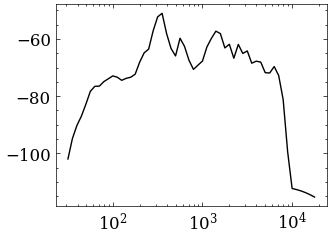

In [64]:
ind = return_real_index_from_fan(AUDIO_PCA_OUTLIERED, 63)
print(ind)
plt.semilogx(CENTRE_FREQS, n_curves[ind], color='k')
plt.show()

[0.024 0.032 0.04  0.048 0.056 0.064 0.072 0.08  0.088 0.096 0.104 0.112
 0.12  0.128 0.136 0.144 0.152 0.16  0.168 0.176]


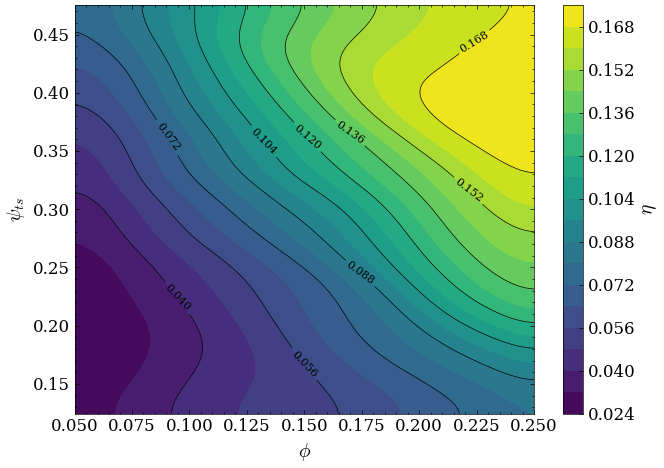

In [65]:
x = np.concatenate(phi_vals)  # x coordinates (phi values)
y = np.concatenate(p_curves)  # y coordinates  
# z = np.concatenate(e_curves)  # z value at each (x, y) point
z = np.array([val for arr in e_curves for val in arr], dtype=float)

xi = np.linspace(min(x), max(x), 100)
yi = np.linspace(min(y), max(y), 100)
Xi, Yi = np.meshgrid(xi, yi)

# Filter source points
# valid = y >= 3.75 * x**2
# x, y, z = x[valid], y[valid], z[valid]

# Build a KD-tree from your scattered points
tree = cKDTree(np.column_stack([x, y]))

# Query the n nearest neighbors for every grid point
n = 200  # number of nearest neighbors to average
distances, indices = tree.query(np.column_stack([Xi.ravel(), Yi.ravel()]), k=n)

# Simple average of n nearest z values
# Zi = z[indices].mean(axis=1).reshape(Xi.shape)

# --- OR: inverse-distance weighted average (closer points count more) ---
weights = 1 / (distances + 1e-10)  # avoid division by zero
Zi = (weights * z[indices]).sum(axis=1) / weights.sum(axis=1)
Zi = Zi.reshape(Xi.shape)

Zi = gaussian_filter(Zi, sigma=5)  # smoothing

# mask = Yi < 3.75 * Xi**2
# Zi_masked = np.ma.masked_where(mask, Zi)
levels = np.arange(0.024, 0.184, 0.008)
label_levels = np.arange(0.024, 0.184, 0.016)
print(levels)

fig, ax = plt.subplots(figsize=(7, 5))
cp = ax.contourf(Xi, Yi, Zi, levels=levels, cmap='viridis')  # filled contours
cs = ax.contour(Xi, Yi, Zi, levels=label_levels, colors='black', linewidths=0.5)  # contour lines
ax.clabel(cs, inline=True, fontsize=8)  # label the lines
# ax.set_xlim(0,0.3)
# ax.set_ylim(0.1,0.5)
ax.set_xlabel('$\phi$')
ax.set_ylabel('$\psi_{ts}$')
fig.colorbar(cp, label=r'$\eta$')
plt.tight_layout()
plt.savefig(f'C:\\Users\\angus\\OneDrive\\Documents\\Cambridge\\Year 4\\Project\\diagrams for final report\\gp_contour_plots_smith_chart.svg', bbox_inches='tight')
plt.show()

In [66]:
print(min(max_phis),max(max_phis),np.min(np.concatenate(p_curves)),np.max(np.concatenate(p_curves)))

0.3326759397434476 0.5828178691322602 0.12447219319798311 0.47536498598129895


-25.4203947357224


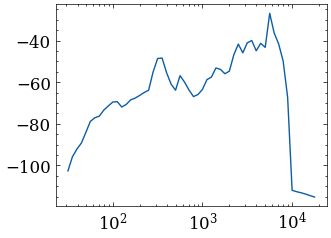

In [67]:
freqs, amps = get_curve_from_params(AUDIO_PCA_OUTLIERED, GP_AUDIO, AUDIO_PCA_OUTLIERED.params[return_real_index_from_fan(AUDIO_PCA_OUTLIERED, 63)])
print(calculate_oaspl(amps))
plt.semilogx(freqs, amps)
plt.show()

In [68]:
import joblib
centre_freqs = CENTRE_FREQS
pca_pressure   = joblib.load("../GPS_PKL/pca_pressure.pkl")
pca_efficiency = joblib.load("../GPS_PKL/pca_efficiency.pkl")
pca_noise      = joblib.load("../GPS_PKL/pca_noise.pkl")
gp_pressure   = joblib.load("../GPS_PKL/gp_pressure.pkl")
gp_efficiency = joblib.load("../GPS_PKL/gp_efficiency.pkl")
gp_noise      = joblib.load("../GPS_PKL/gp_noise.pkl")

In [69]:
def contour_plot_vals_from_params(params):
    phi_max_vals = []
    psi_max_vals = []
    eta_max_vals = []
    oaspl_vals = []

    with tqdm(total=len(params), desc="Loading runs") as pbar:
        for i, param in enumerate(params):
            # Call GPs to get curves
            phi_vals, p_curve, _ = get_curve_from_params(pca_pressure, gp_pressure, param)
            _, e_curve, _ = get_curve_from_params(pca_efficiency, gp_efficiency, param)
            _, n_curve = get_curve_from_params(pca_noise, gp_noise, param)
            
            # Evaluate curves to get desired params
            phi_max = axes_crossing(phi_vals, p_curve)[1]
            # print(phi_max)
            psi_max = np.max(p_curve)
            eta_max = np.max(e_curve)
            oaspl = calculate_oaspl(n_curve)
            # print(oaspl)
            
            # Append to lists for plotting
            phi_max_vals.append(phi_max)
            psi_max_vals.append(psi_max)
            eta_max_vals.append(eta_max)
            oaspl_vals.append(oaspl)
            pbar.update(1)
            
    return np.array(phi_max_vals), np.array(psi_max_vals), np.array(eta_max_vals), np.array(oaspl_vals)

def build_kd_tree_and_interpolate(x, y, xi, yi, n_neighbors=5):
    # Build a KD-tree from your scattered points
    tree = cKDTree(np.column_stack([x, y]))

    # Query the n nearest neighbors for every grid point
    distances, indices = tree.query(np.column_stack([xi.ravel(), yi.ravel()]), k=n_neighbors)

    # --- inverse-distance weighted average (closer points count more) ---
    weights = 1 / (distances + 1e-10)  # avoid division by zero
    return weights, indices

def blade_shapes():
    # Take params from csv
    file = '../doe_params.csv'
    data = pd.read_csv(file, index_col=None)
    # data = data.iloc[-5:]
    # print(data.head())
    # stopping = input("press enter to continue")
    xs=[]
    ys=[]
    filenames = os.listdir("..\\throughflow_output")
    for i, row in data.iterrows():
        if i != 59 and i!=61 and i!=35 and i!=56:
            continue
        # rows: ['mdot', 'DH_mid', 'incidence', 'Vexp', 'lean_compound', 'lean_straight', 'tip_clearance', 'n_blade']
        ### input params
        index = i
        n_blades = row['n_blade']
        rhub=0.015             # 15 mm hub radius
        rcase=0.040             # 40 mm case radius
        tip_clearance_percent = row['tip_clearance']
        tip_clearance_abs = tip_clearance_percent/100*rcase
        rtip = rcase-tip_clearance_abs
        RPM=3000.0             # 3000 rpm
        mdot=row['mdot']              # 0.05 kg/s (further reduced for better blade effect)
        DHmid=row['DH_mid']              # De Haller number = 0.9 (diffusion)
        INC=row['incidence']                # 2° incidence
        Vexp=row['Vexp']               # Vortex exponent 
        lean_max = row['lean_compound']        # Angle (degrees) of max lean
        lean_weighting = 1   # Form of lean curve (r*(1-r))**lean_weighting
        lean_straight = row['lean_straight'] # Straight lean angle (degrees)
        # filename = f"DOE_{index}_{n_blades}_{mdot:.4f}_{DHmid:.4f}_{INC:.2f}_{Vexp:.4f}_{lean_max:.4f}_{lean_weighting}_{lean_straight:.2f}_{tip_clearance_percent:.3f}"
        for f in filenames:
                if re.search(rf"DOE_{index}", f) and f.endswith("blade_sections.npz"):
                    filename = f
                    # stl_file = f[:-4]   # strip .stl
        # filename = f"DOE_{index}_{n_blades}_{mdot}_{DHmid}_{INC}_{Vexp}_{lean_max}_{lean_weighting}_{lean_straight}_{tip_clearance_percent}"
        # print(filename)
        # print(os.getcwd())
        os.chdir('../throughflow_output')
        # print(os.getcwd)
        output_filename =  filename#+"_blade_sections.npz"'../throughflow_output/'
        section_data = np.load(output_filename, allow_pickle=True)['sections'].item()['R1']
        from fan_generator_from_params import convert_to_cartesian,smooth_trailing_edges,convert_to_cylindrical
    
        XYZ_sections = []
        # Convert all section data to cartesian coordinates for stl generation
        for i, section in enumerate(section_data):
            X_cart, Y_cart, Z_cart = convert_to_cartesian(section)
            XYZ_sections.append(np.stack([X_cart, Y_cart, Z_cart], axis=1))

        # Make trailing edges
        XYZ_sections_complete = smooth_trailing_edges(XYZ_sections)
        
        midspan_index = len(section_data)-1
        midspan_shape = XYZ_sections_complete[midspan_index]
        # # print(midspan_shape, np.shape(midspan_shape))
        
        def xyz_to_cylindrical(vectors):
            """
            Convert a list of Cartesian (x, y, z) vectors to cylindrical (r, theta, z) coordinates.
            
            Parameters:
                vectors : array-like, shape (N, 3) - list of [x, y, z] vectors
            
            Returns:
                numpy array, shape (N, 3) - array of [r, theta, z] vectors
                where r is radial distance, theta is in radians, z is axial
            """
            vectors = np.array(vectors)
            
            x = vectors[:, 0]
            y = vectors[:, 1]
            z = vectors[:, 2]
            
            r     = np.sqrt(x**2 + y**2)
            theta = np.arctan2(y, x)   # returns values in [-pi, pi]
            
            return r, theta, z
        
        r,theta,z = xyz_to_cylindrical(midspan_shape)
        x = z#section_data[midspan_index]['x']
        y = r*theta#section_data[midspan_index]['theta']#np.multiply(section_data[midspan_index]['r'],)
        
        # print(mdot, DHmid)
        xs.append(x)
        ys.append(y)
        # import matplotlib.pyplot as plt
        # from mpl_toolkits.axes_grid1.inset_locator import inset_axes

        # fig, ax = plt.subplots()
        # ax.plot(z,np.multiply(r,theta))
        
        # inset = inset_axes(ax, width="30%", height="30%", loc="upper right")
        # inset.plot(z,np.multiply(r,theta), color="coral")
        # inset.axis("off")
        
        # ax.grid()
        # plt.show()
        # print(mdot,DHmid)
    return xs,ys

def contour_plot_2x2(x, y, params, xlabel, ylabel, x_filename, y_filename):
    # Find the unique x and y values to get grid dimensions
    nx = len(np.unique(x))
    ny = len(np.unique(y))
    # Reshape into 2D grids
    X = x.reshape(ny, nx)
    Y = y.reshape(ny, nx)
    
    # v_min_psi = 0.10
    # v_max_psi = 0.50
    # psi_levels = np.linspace(v_min_psi, v_max_psi, int((v_max_psi-v_min_psi)/0.05)+1)
    # v_min_eta = 0.03
    # v_max_eta = 0.2
    # eta_levels = np.linspace(v_min_eta, v_max_eta, int((v_max_eta-v_min_eta)/0.01)+1)
    # v_min_phi = 0.15
    # v_max_phi = 0.95
    # phi_levels = np.linspace(v_min_phi, v_max_phi, int((v_max_phi-v_min_phi)/0.05)+2)
    # print(phi_levels)
    # v_min_oaspl = -47.5
    # v_max_oaspl = -41
    # oaspl_levels = np.linspace(v_min_oaspl, v_max_oaspl, int((v_max_oaspl-v_min_oaspl)/0.5)+1)

    def quadruple_levels(levels):
        new_levels = []
        for i in range(len(levels)-1):
            new_levels.append(levels[i])
            new_levels.append(levels[i]+(levels[i+1]-levels[i])/4)
            new_levels.append(levels[i]+(levels[i+1]-levels[i])/2)
            new_levels.append(levels[i]+3*(levels[i+1]-levels[i])/4)
        new_levels.append(levels[-1])
        return np.array(new_levels)
    
    
    # print(phi_levels)
    
    phi_max_vals, psi_max_vals, eta_max_vals, oaspl_vals = contour_plot_vals_from_params(params)
    # print(oaspl_vals[return_real_index_from_fan(AUDIO_PCA_OUTLIERED, 63)])
    
    smoothing_blades = (0,0)
    
    fig, ax = plt.subplots(2, 2, figsize=(10, 10), sharex=True, sharey=True)
    
    # from mpl_toolkits.axes_grid1.inset_locator import inset_axes
    # if x_filename=="m_dot":
    #     xs,ys = blade_shapes()
    #     def insert_blade(loc,idx):
    #         inset = inset_axes(ax[0,0], width="30%", height="30%", loc=loc)
    #         inset.plot(xs[idx],ys[idx], color="coral")
    #         inset.axis("off")
    #     insert_blade("upper left",2)
    #     insert_blade("lower left",3)
    #     insert_blade("upper right",0)
    #     insert_blade("lower right",1)
    

    # Max psi contour plot
    z = np.array(psi_max_vals)  # z value at each (x, y) point
    Z = z.reshape(ny, nx)
    Z = gaussian_filter(Z, sigma = smoothing_blades)
    # cp = ax[0, 0].contourf(X, Y, Z, levels=quadruple_levels(psi_levels), cmap='viridis', vmin=v_min_psi, vmax=v_max_psi)  # filled contours
    # cs = ax[0, 0].contour(X, Y, Z, levels=psi_levels, colors='black', linewidths=0.5)  # contour lines
    cp = ax[0, 0].contourf(X, Y, Z, levels=20,cmap='viridis')  # filled contours
    cs = ax[0, 0].contour(X, Y, Z, levels=cp.levels[::2], colors='black', linewidths=0.5)  # contour lines
    ax[0, 0].clabel(cs, inline=True, fontsize=8)  # label the lines
    ax[0, 0].set_ylabel(ylabel)
    ax[0,0].set_title(r'$\psi_{ts, max}$')
    if y_filename == "blade_count":
        ax[0, 0].set_yticks([5,6,7,8,9])

    # Max phi contour plot
    z = np.array(phi_max_vals)  # z value at each (x, y) point
    Z = z.reshape(ny, nx)
    Z = gaussian_filter(Z, sigma=1.0)
    # cp = ax[1, 0].contourf(X, Y, Z, levels=quadruple_levels(phi_levels), cmap='viridis', vmin=v_min_phi, vmax=v_max_phi)  # filled contours
    # cs = ax[1, 0].contour(X, Y, Z, levels=phi_levels, colors='black', linewidths=0.5)  # contour lines
    cp = ax[1, 0].contourf(X, Y, Z, levels=20,cmap='viridis')  # filled contours
    cs = ax[1, 0].contour(X, Y, Z, levels=cp.levels[::2],colors='black', linewidths=0.5)  # contour lines
    ax[1, 0].clabel(cs, inline=True, fontsize=8)  # label the lines
    ax[1, 0].set_xlabel(xlabel)
    ax[1, 0].set_ylabel(ylabel)
    ax[1, 0].set_title(r'$\phi_{max}$')
    if y_filename == "blade_count":
        ax[1, 0].set_yticks([5,6,7,8,9])

    # Max eta contour plot
    z = np.array(eta_max_vals)  # z value at each (x, y) point
    Z = z.reshape(ny, nx)
    Z = gaussian_filter(Z, sigma = smoothing_blades)
    # cp = ax[0, 1].contourf(X, Y, Z, levels=quadruple_levels(eta_levels), cmap='viridis', vmin=v_min_eta, vmax=v_max_eta)  # filled contours
    # cs = ax[0, 1].contour(X, Y, Z, levels=eta_levels, colors='black', linewidths=0.5)  # contour lines
    cp = ax[0, 1].contourf(X, Y, Z, levels=20,cmap='viridis')  # filled contours
    cs = ax[0, 1].contour(X, Y, Z,levels=cp.levels[::2], colors='black', linewidths=0.5)  # contour lines
    ax[0, 1].clabel(cs, inline=True, fontsize=8)
    ax[0, 1].set_title(r'$\eta_{max}$')
    if y_filename == "blade_count":
        ax[0, 1].set_yticks([5,6,7,8,9])

    # Max OASPL contour plot
    z = np.array(oaspl_vals)  # z value at each (x, y) point
    Z = z.reshape(ny, nx)
    Z = gaussian_filter(Z, sigma = smoothing_blades)
    # cp = ax[1, 1].contourf(X, Y, Z, levels=quadruple_levels(oaspl_levels), cmap='viridis_r', vmin=v_min_oaspl, vmax=v_max_oaspl)  # filled contours
    # cs = ax[1, 1].contour(X, Y, Z, levels=oaspl_levels, colors='black', linewidths=0.5)  # contour lines
    cp = ax[1, 1].contourf(X, Y, Z,levels=20, cmap='viridis')  # filled contours
    cs = ax[1, 1].contour(X, Y, Z, levels=cp.levels[::2],colors='black', linewidths=0.5)  # contour lines
    ax[1, 1].clabel(cs, inline=True, fontsize=8)
    ax[1, 1].set_xlabel(xlabel)
    ax[1, 1].set_title('$OASPL$')
    if y_filename == "blade_count":
        ax[1, 1].set_yticks([5,6,7,8,9])

    # fig.colorbar(cp, label=r'$\psi_{ts, max}$')
    plt.tight_layout()
    plt.savefig(f'C:\\Users\\angus\\OneDrive\\Documents\\Cambridge\\Year 4\\Project\\diagrams for final report\\gp_contour_plots_{x_filename}_{y_filename}.svg', bbox_inches='tight')
    plt.show()


Loading runs: 100%|██████████| 2500/2500 [00:23<00:00, 105.73it/s]


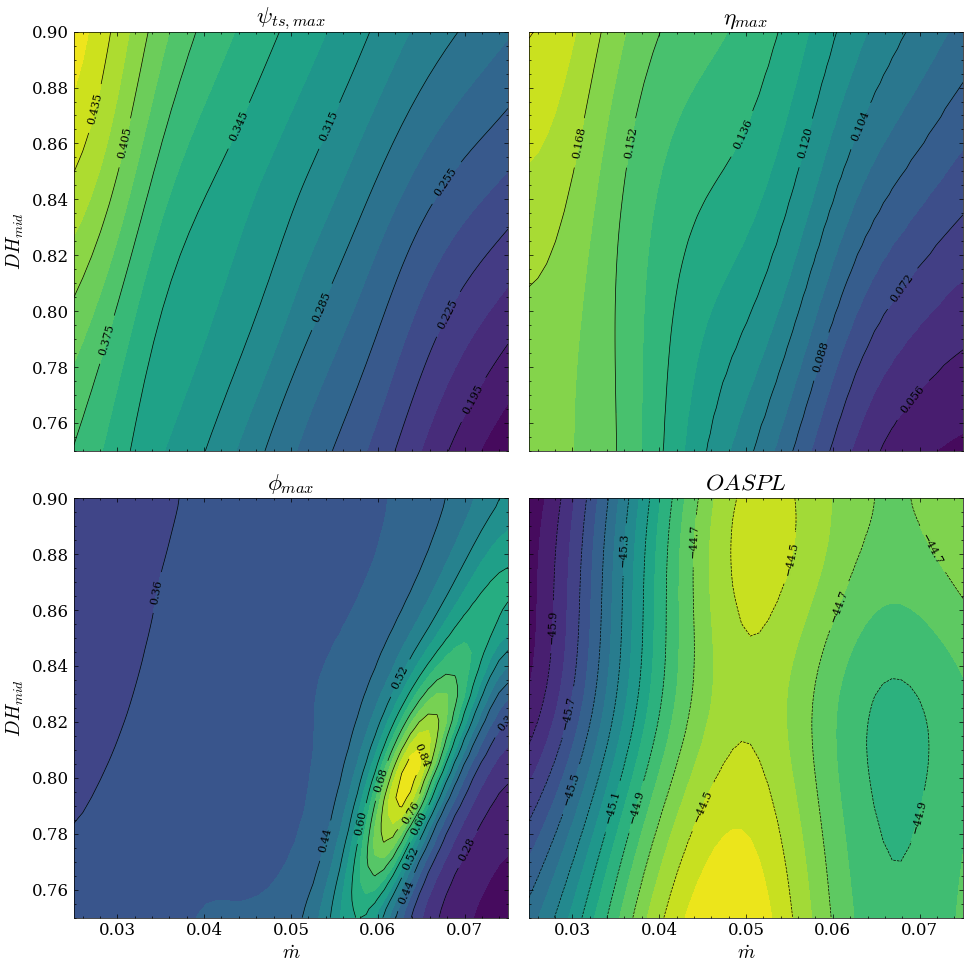

In [70]:
# m_dot and dh parameters
test_index_m_dot = 0
test_index_dh = 1
m_dots = np.linspace(PARAM_LO[0], PARAM_HI[0], 50)
dh_vals = np.linspace(PARAM_LO[1], PARAM_HI[1],50)

test_points_variable = np.array([[m, dh] for m in m_dots for dh in dh_vals])
# print(test_points_variable)
test_points_fixed = PARAM_DEFAULTS[2:]
test_params = np.array([np.concatenate([test_point, test_points_fixed]) for test_point in test_points_variable])

x = test_points_variable[:, 0]  # x coordinates (phi values)
y = test_points_variable[:, 1]  # y coordinates  

contour_plot_2x2(x, y, test_params, xlabel=r'$\dot{m}$', ylabel=r'$DH_{mid}$', x_filename='m_dot', y_filename='dh')

Loading runs: 100%|██████████| 2500/2500 [00:23<00:00, 107.57it/s]


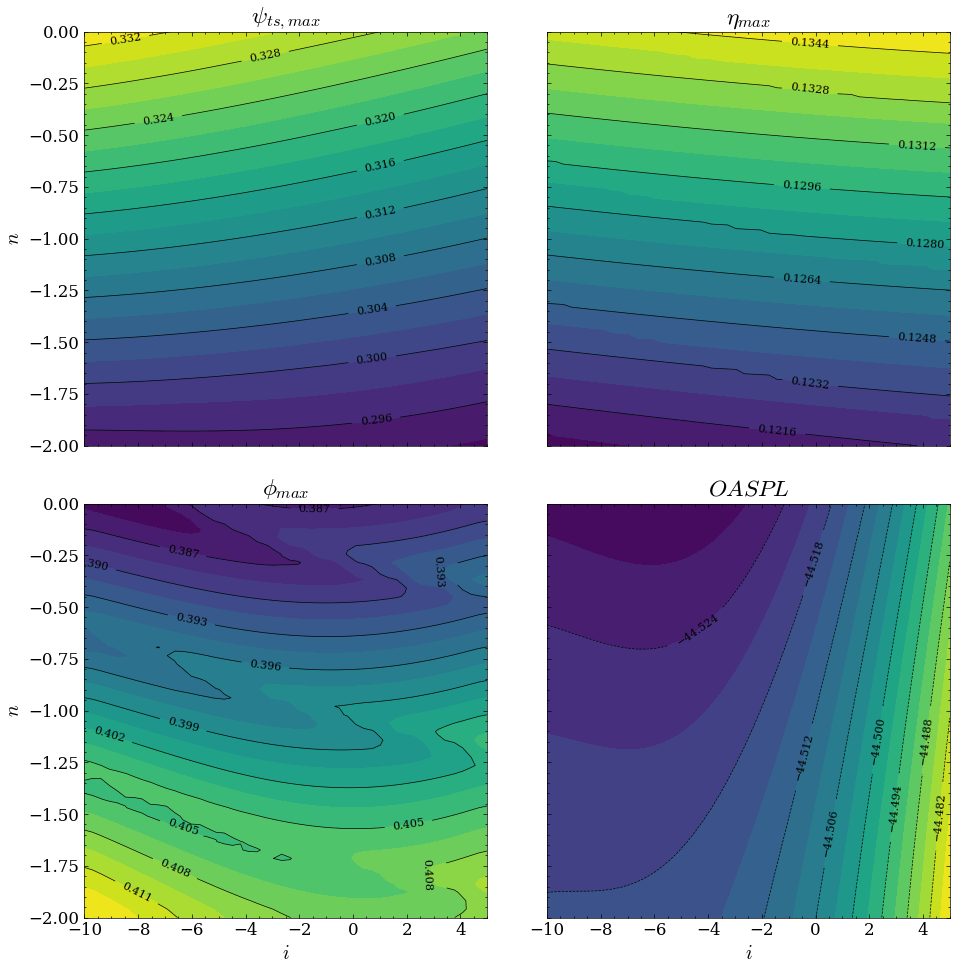

In [71]:
# incidence and vortex exp parameters
test_index_inc = 2
test_index_vexp = 3
incs = np.linspace(PARAM_LO[2], PARAM_HI[2], 50)
vexps = np.linspace(PARAM_LO[3], PARAM_HI[3], 50)

test_points_variable = np.array([[inc, vexp] for inc in incs for vexp in vexps])
test_points_fixed_less = PARAM_DEFAULTS[:2]
test_points_fixed_more = PARAM_DEFAULTS[4:]
# print(test_points_fixed_less, test_points)
test_params = np.array([np.concatenate([test_points_fixed_less, test_point, test_points_fixed_more]) for test_point in test_points_variable])

x = test_points_variable[:, 0]  # x coordinates (phi values)
y = test_points_variable[:, 1]  # y coordinates  

contour_plot_2x2(x, y, test_params, xlabel=r'$i$', ylabel=r'$n$', x_filename='inc', y_filename='vexp')

Loading runs:   0%|          | 0/2500 [00:00<?, ?it/s]

Loading runs: 100%|██████████| 2500/2500 [00:22<00:00, 111.77it/s]


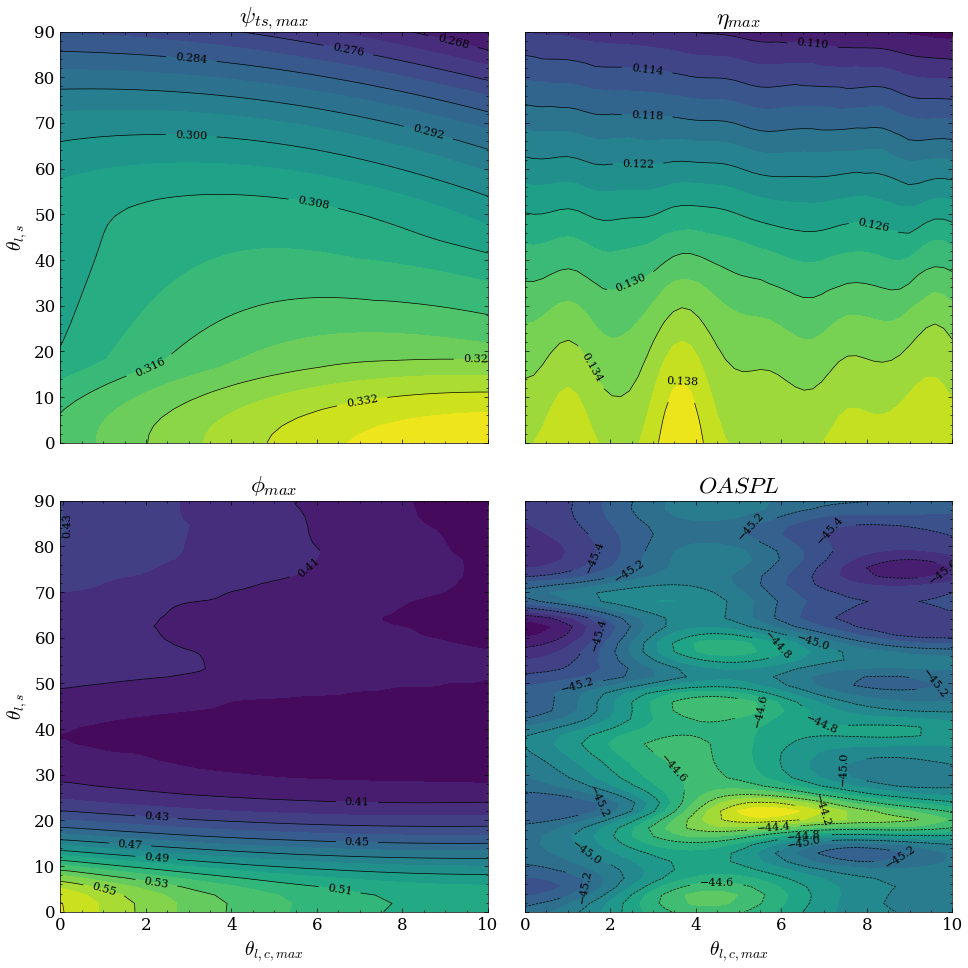

In [72]:
# compound lean and straight lean parameters
test_index_c_lean = 4
test_index_s_lean = 5
c_leans = np.linspace(PARAM_LO[4], PARAM_HI[4], 50)
s_leans = np.linspace(PARAM_LO[5], PARAM_HI[5], 50)

test_points_variable = np.array([[c_lean, s_lean] for c_lean in c_leans for s_lean in s_leans])
test_points_fixed_less = PARAM_DEFAULTS[:4]
test_points_fixed_more = PARAM_DEFAULTS[6:]
# print(test_points_fixed_less, test_points)
test_params = np.array([np.concatenate([test_points_fixed_less, test_point, test_points_fixed_more]) for test_point in test_points_variable])

x = test_points_variable[:, 0]  # x coordinates (phi values)
y = test_points_variable[:, 1]  # y coordinates  

contour_plot_2x2(x, y, test_params, xlabel=r'$\theta_{l,c,max}$', ylabel=r'$\theta_{l,s}$', x_filename='compound_lean', y_filename='straight_lean')

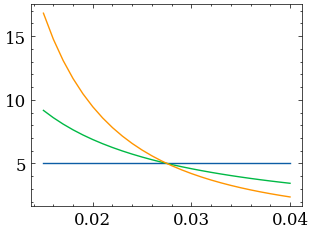

In [73]:
r_hub = 0.015
r_tip = 0.040
step = 0.001
r = np.arange(r_hub,r_tip+step, step)
r_mid = 0.0275
u_mid = 5

plt.plot(r, u_mid*(r/r_mid)**0)
plt.plot(r, u_mid*(r/r_mid)**-1)
plt.plot(r, u_mid*(r/r_mid)**-2)
plt.show()

Loading runs: 100%|██████████| 250/250 [00:02<00:00, 107.44it/s]


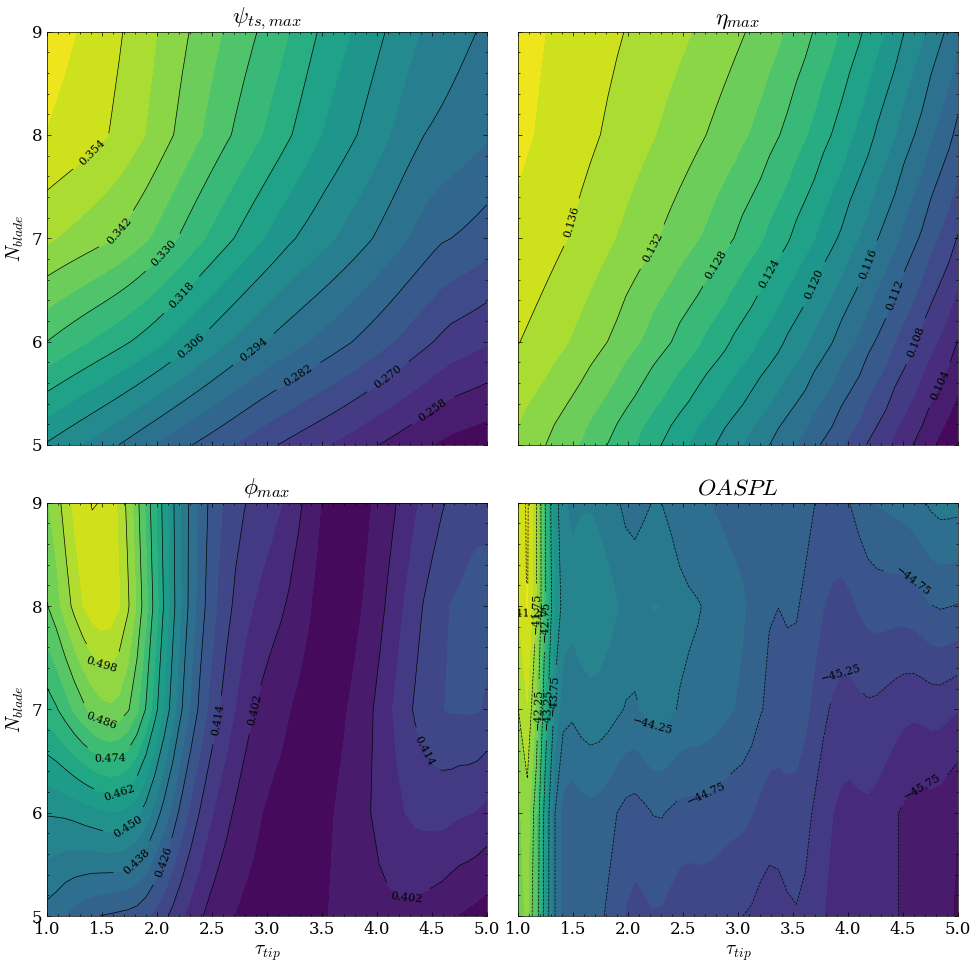

In [74]:
# tip clearance and blade count parameters
test_index_tip = 6
test_index_blade = 7
tips = np.linspace(PARAM_LO[6], PARAM_HI[6], 50)
blades = np.linspace(PARAM_LO[7], PARAM_HI[7], 5, endpoint=True)
# print(blades)

test_points_variable = np.array([[tip, blade] for tip in tips for blade in blades])
test_points_fixed_less = PARAM_DEFAULTS[:6]
test_points_fixed_more = PARAM_DEFAULTS[8:]
# print(test_points_fixed_less, test_points)
test_params = np.array([np.concatenate([test_points_fixed_less, test_point, test_points_fixed_more]) for test_point in test_points_variable])

x = test_points_variable[:, 0]  # x coordinates (phi values)
y = test_points_variable[:, 1]  # y coordinates  
idx = np.lexsort((x,y))
x, y, test_params = x[idx], y[idx], test_params[idx]

contour_plot_2x2(x, y, test_params, xlabel=r'$\tau_{tip}$', ylabel=r'$N_{blade}$', x_filename='tip_clearance', y_filename='blade_count')

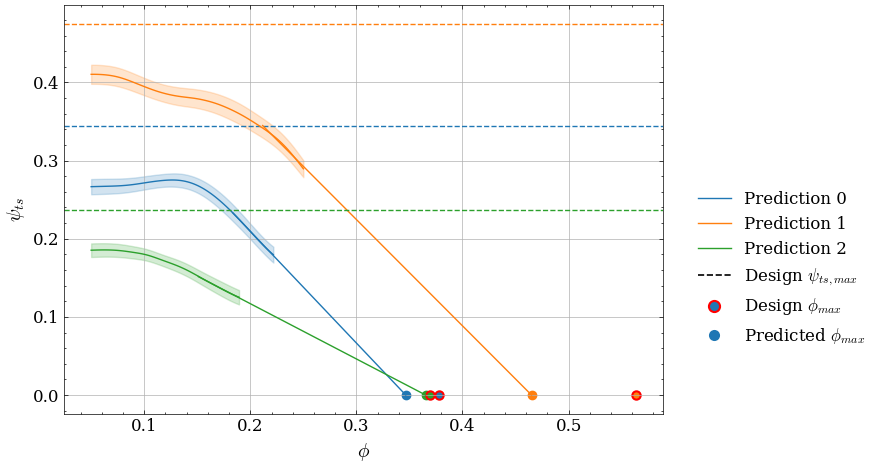

In [75]:
results = pd.read_csv(r'..\optimisation_results_2.csv')
input_params = pd.read_csv(r'..\fan_inverse_design_parameters.csv')
from pca_core import CENTRE_FREQS
import joblib

centre_freqs = CENTRE_FREQS
pca_pressure   = joblib.load("../GPS_PKL/pca_pressure.pkl")
pca_efficiency = joblib.load("../GPS_PKL/pca_efficiency.pkl")
pca_noise      = joblib.load("../GPS_PKL/pca_noise.pkl")
gp_pressure   = joblib.load("../GPS_PKL/gp_pressure.pkl")
gp_efficiency = joblib.load("../GPS_PKL/gp_efficiency.pkl")
gp_noise      = joblib.load("../GPS_PKL/gp_noise.pkl")


n_points = 10
cmap = cm.get_cmap('tab10')  # or 'viridis', 'plasma', 'hsv', etc.
colours = [cmap(i / n_points) for i in range(n_points)]

fig, ax = plt.subplots( figsize=(7,5), sharex=False)

for i, res in results.iterrows():
    # if i >= 2 and i<=4:
    #     continue
    
    # if i==5:
    #     i=2
    # elif i==6:
    #     i=3

    params = res.iloc[:8].to_numpy()

    # Predict curves with design params
    p_curve = pca_pressure.reconstruct(gp_pressure.predict(params)[0])
    e_curve = pca_efficiency.reconstruct(gp_efficiency.predict(params)[0])
    n_curve = pca_noise.reconstruct(gp_noise.predict(params)[0])
    
    m_psi, s_psi, s_m_psi, s_s_psi, e_m_psi, e_s_psi = gp_pressure.predict(params)
    m_eta, s_eta, s_m_eta, s_s_eta, e_m_eta, e_s_eta = gp_efficiency.predict(params)
    m_noise, s_noise = gp_noise.predict(params)
    
    phi_end_m = gp_pressure.predict(params)[4]
    mask = PHI_COMMON < phi_end_m
    
    p_curve = p_curve[mask]
    e_curve = e_curve[mask]
    PHI_PLOT = PHI_COMMON[mask]
    
    # var       = sum((pca_efficiency.modes[k] * s_eta[k]) ** 2 for k in range(pca_efficiency.n_modes))
    # std       = np.sqrt(var)[mask]

    
    # if i == 0:
    #     ax[0].fill_between(PHI_PLOT, pca_efficiency.reconstruct(m_eta)[mask]-std, pca_efficiency.reconstruct(m_eta)[mask]+std, color=colours[i], alpha=0.2, zorder=0, label=f'GP predicted $\pm1\sigma$')
    # else:
    #     ax[0].fill_between(PHI_PLOT, pca_efficiency.reconstruct(m_eta)[mask]-std, pca_efficiency.reconstruct(m_eta)[mask]+std, color=colours[i], alpha=0.2, zorder=0)
    # ax[0].plot(PHI_PLOT, e_curve, color=colours[i], label=f'Prediction {i}')

    # PSI
    var       = sum((pca_pressure.modes[k] * s_psi[k]) ** 2 for k in range(pca_pressure.n_modes))
    std       = np.sqrt(var)[mask]

    ax.plot(PHI_PLOT, p_curve, color=colours[i], label=f'Prediction {i}')
    ax.fill_between(PHI_PLOT, pca_pressure.reconstruct(m_psi)[mask]-std, pca_pressure.reconstruct(m_psi)[mask]+std, color=colours[i], alpha=0.2, zorder=0)
    n_points = 20    
    m, c, r, p, se = stats.linregress(PHI_PLOT[-n_points:], p_curve[-n_points:])
    x_crossing = -c/m
    x = np.linspace(PHI_PLOT[-n_points],x_crossing,50)
    ax.plot(x,m*x+c,color=colours[i])
    ax.scatter(x_crossing,0,marker='o',color=colours[i])
    target_x = input_params["phi_target"].iloc[i]
    target_y = input_params["psi_target"].iloc[i]
    ax.scatter(target_x,0,color=colours[i],edgecolors='red', linewidths= 1.5)
    ax.axhline(target_y,linestyle='--',color=colours[i])

    
    
    # Noise
    # var       = sum((pca_noise.modes[k] * s_noise[k]) ** 2 for k in range(pca_noise.n_modes))
    # std       = np.sqrt(var)

    # ax[2].semilogx(centre_freqs, n_curve, color=colours[i])
    # ax[2].fill_between(centre_freqs, pca_noise.reconstruct(m_noise)-std, pca_noise.reconstruct(m_noise)+std, color=colours[i], alpha=0.2, zorder=0)
    
    
# ax[0].grid()
# ax[0].set_xlabel(r'$\phi$')
# ax[0].set_ylabel(r'$\eta$')

ax.grid()
ax.set_xlabel(r'$\phi$')
ax.set_ylabel(r'$\psi_{ts}$')
# ax.set_xlim(0,0.6)
# ax.set_ylim(-0.01,0.5)

# ax[2].grid()
# ax[2].set_xlabel('Frequency (Hz)')
# ax[2].set_ylabel('SPL (dBAFS)')

existing_handles, existing_labels = ax.get_legend_handles_labels()

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='black', linestyle='--', linewidth=1.2,
           label=r'Design $\psi_{ts, max}$'),
    Line2D([0], [0], marker='o', color='none',
           markerfacecolor=colours[0], markeredgecolor='red', markeredgewidth=1.5,
           markersize=8, label=r'Design $\phi_{max}$'),
    Line2D([0], [0], marker='o', color='none',
           markerfacecolor=colours[0], markeredgecolor='none',
           markersize=8, label=r'Predicted $\phi_{max}$'),
]

# ax.legend()


fig.legend(handles=existing_handles + legend_elements,
          labels=existing_labels + [h.get_label() for h in legend_elements], bbox_to_anchor=(1.01, 0.6), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.savefig(r'C:\Users\angus\OneDrive\Documents\Cambridge\Year 4\Project\diagrams for final report\predicted_fan_curves.svg', bbox_inches='tight')
plt.show()

In [76]:
def get_smoothed_curves_from_files(data_filepath, audio_filepath):
    
    curve_df = pd.read_csv(data_filepath)
    curve_df = curve_df[curve_df["dp_venturi_mean"] >= 0].copy()
    # print(curve_df)
    # psi
    end_phi   = float(curve_df["flow_coefficient_mean"].max())
    mean_psi, _, _ = load_with_gp_smooth(
                curve_df["flow_coefficient_mean"],
                curve_df["pressure_rise_coefficient_mean"],
                PHI_COMMON,
            )
    mean_psi = mean_psi[PHI_COMMON < end_phi]
    
    # eta
    mean_eta, _, _ = load_with_gp_smooth(
                curve_df["flow_coefficient_mean"],
                curve_df["efficiency_mean"],
                PHI_COMMON,
            )
    mean_eta = mean_eta[PHI_COMMON < end_phi]
    phi_common_masked = PHI_COMMON[PHI_COMMON < end_phi]
    
    # mean_psi = 0
    # mean_eta = 0
    # phi_common_masked = 0
    # noise
    
    audio_data, sample_rate = librosa.load(audio_filepath, sr=None)
    nperseg = len(audio_data)//8
    noverlap = nperseg//2  
    
    ## Plot ##
    frequencies, power = welch(
        audio_data,
        fs=sample_rate,
        window='blackman',
        nperseg=nperseg,
        noverlap=noverlap,
        scaling = 'spectrum'
        )

    amplitude = np.sqrt(power)
    amplitude_db = 20 * np.log10(amplitude + 1e-12)  
    
    amplitude_db = medfilt(amplitude_db, kernel_size=19)  # kernel must be odd
    # amplitude_db = np.array(pd.DataFrame(amplitude_db).rolling(window=9, center=True, min_periods=1).mean()).flatten()
    octave_freqs, a_weighted_octave_bands = sixth_octave_spectrum_and_a_weight(frequencies, amplitude_db)
    
    return phi_common_masked, mean_psi, mean_eta, octave_freqs, a_weighted_octave_bands


In [77]:
def get_amplitude_freqs_from_filename(filepath):
    audio_data, sample_rate = librosa.load(filepath, sr=None)
    nperseg = len(audio_data)//8
    noverlap = nperseg//2  
    
    frequencies, power = welch(
        audio_data,
        fs=sample_rate,
        window='blackman',
        nperseg=nperseg,
        noverlap=noverlap,
        scaling = 'spectrum'
        )

    amplitude = np.sqrt(power)
    amplitude_db = 20 * np.log10(amplitude + 1e-12)  
    
    amplitude_db = medfilt(amplitude_db, kernel_size=19)  # kernel must be odd
    # amplitude_db = np.array(pd.DataFrame(amplitude_db).rolling(window=9, center=True, min_periods=1).mean()).flatten()
    octave_freqs, a_weighted_octave_bands = sixth_octave_spectrum_and_a_weight(frequencies, amplitude_db)
    
    return octave_freqs, a_weighted_octave_bands
    

In [78]:
octave_freqs, new_octave_bands = get_amplitude_freqs_from_filename("../audio/recording_re-testing-1_20260526_181450.wav")
octave_freqs, a_weighted_octave_bands = get_amplitude_freqs_from_filename("../audio/inverse_design_2/inverse_design_test_1_5.0_0.0615_0.7779_4.39_-0.3988_8.9207_1_74.55_3.305blade.wav")

difference_db = a_weighted_octave_bands-new_octave_bands

In [79]:
def get_nrmse_and_stats_inverse_pred(curve_pred, curve_real):
    X = curve_real
    X_reconstructed = curve_pred
    min = np.min(X)
    max = np.max(X)
    max_min = max - min
    
    rmse = np.sqrt(mean_squared_error(X, X_reconstructed))/max_min *100
    
    return rmse

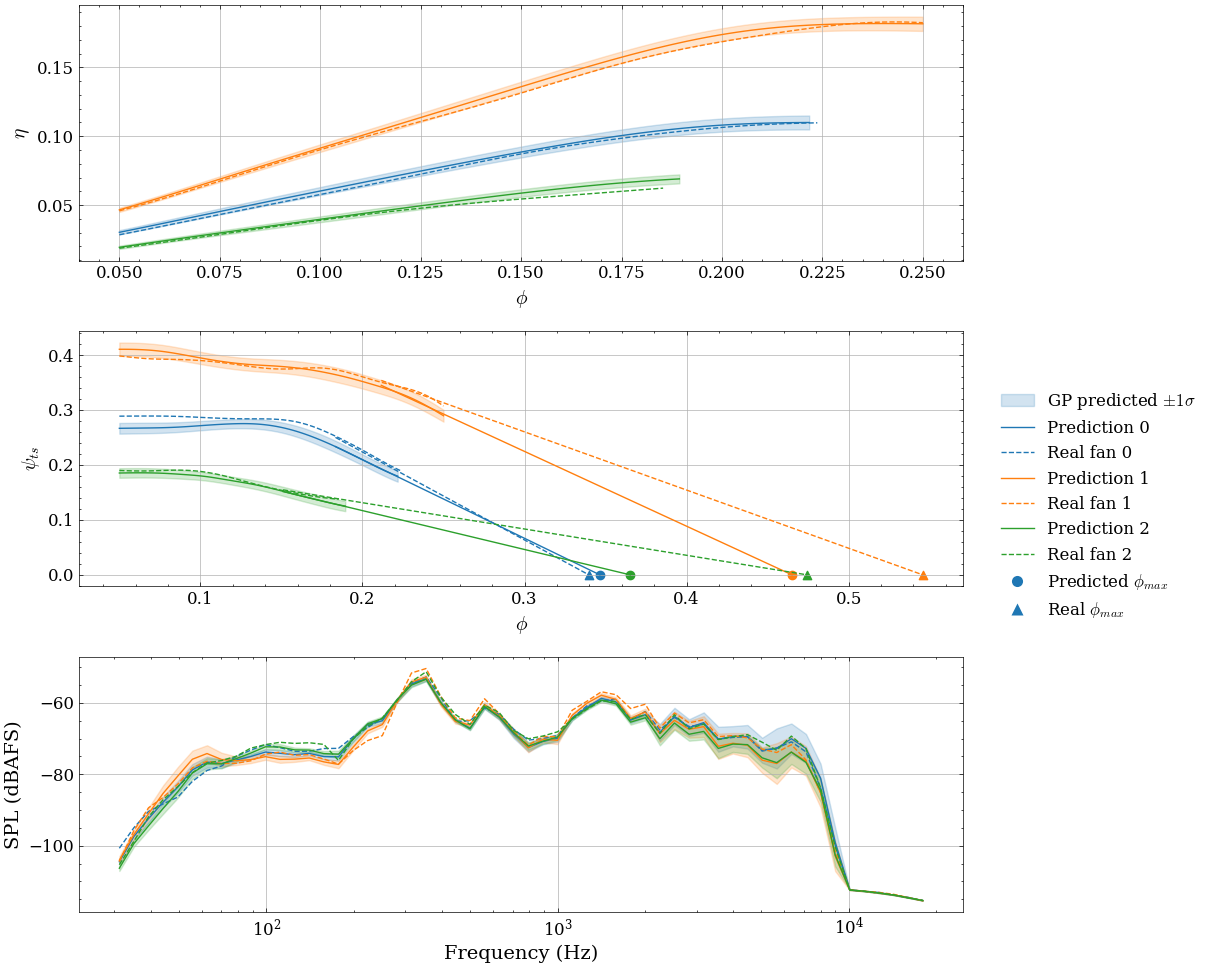

In [80]:
results = pd.read_csv(r'..\optimisation_results_2.csv')
from pca_core import CENTRE_FREQS
import joblib

centre_freqs = CENTRE_FREQS
pca_pressure   = joblib.load("../GPS_PKL/pca_pressure.pkl")
pca_efficiency = joblib.load("../GPS_PKL/pca_efficiency.pkl")
pca_noise      = joblib.load("../GPS_PKL/pca_noise.pkl")
gp_pressure   = joblib.load("../GPS_PKL/gp_pressure.pkl")
gp_efficiency = joblib.load("../GPS_PKL/gp_efficiency.pkl")
gp_noise      = joblib.load("../GPS_PKL/gp_noise.pkl")


n_points = 10
cmap = cm.get_cmap('tab10')  # or 'viridis', 'plasma', 'hsv', etc.
colours = [cmap(i / n_points) for i in range(n_points)]

fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(10, 10), sharex=False)

files = os.listdir('../data/inverse_design_2/')
audio_files = os.listdir('../audio/inverse_design_2/')

pred_phi_maxs = []
pred_psi_maxs = []
pred_eta_maxs = []
pred_oaspls = []

real_psi_maxs = []
real_phi_maxs = []
real_eta_maxs = []
real_oaspls = []

nrmses_psi = []
nrmses_eta = []
nrmses_noise = []

for i, res in results.iterrows():
    # if i == 0:
    #     continue
    
    # if i >= 2 and i<=4:
    #     continue
    
    # if i==5:
    #     i=2
    # elif i==6:
    #     i=3
        
    # Load data
    file_name = files[i]
    filepath = f'../data/inverse_design_2/{file_name}'
    audio_file_name = audio_files[i]
    audio_filepath = f'../audio/inverse_design_2/{audio_file_name}'
    
    # print(filepath, audio_filepath)
    
    phi_common_masked, mean_psi, mean_eta, octave_freqs, a_weighted_octave_bands = get_smoothed_curves_from_files(filepath, audio_filepath)    
    if i==0:
        a_weighted_octave_bands = a_weighted_octave_bands# + difference_db
    
    real_psi_maxs.append(np.max(mean_psi))
    real_phi_maxs.append(axes_crossing(phi_common_masked, mean_psi)[1])
    real_eta_maxs.append(np.max(mean_eta))
    real_oaspls.append(calculate_oaspl(a_weighted_octave_bands))
    
    
    params = res.iloc[:8].to_numpy()

    # Predict curves with design params
    p_curve = pca_pressure.reconstruct(gp_pressure.predict(params)[0])
    e_curve = pca_efficiency.reconstruct(gp_efficiency.predict(params)[0])
    n_curve = pca_noise.reconstruct(gp_noise.predict(params)[0])
    
    
    
    m_psi, s_psi, s_m_psi, s_s_psi, e_m_psi, e_s_psi = gp_pressure.predict(params)
    m_eta, s_eta, s_m_eta, s_s_eta, e_m_eta, e_s_eta = gp_efficiency.predict(params)
    m_noise, s_noise = gp_noise.predict(params)
    
    phi_end_m = gp_pressure.predict(params)[4]
    mask = PHI_COMMON < phi_end_m
    
    p_curve = p_curve[mask]
    e_curve = e_curve[mask]
    PHI_PLOT = PHI_COMMON[mask]
    
    pred_phi_maxs.append(axes_crossing(PHI_COMMON, p_curve)[1])
    pred_psi_maxs.append(np.max(p_curve))
    pred_eta_maxs.append(np.max(e_curve))
    pred_oaspls.append(calculate_oaspl(n_curve))
    
    # NRMSEs
    min_val_psi = np.min([len(p_curve), len(mean_psi)])
    min_val_eta = np.min([len(e_curve), len(mean_eta)])

    rmse_psi = get_nrmse_and_stats_inverse_pred(p_curve[:min_val_psi], mean_psi[:min_val_psi])
    rmse_eta = get_nrmse_and_stats_inverse_pred(e_curve[:min_val_eta], mean_eta[:min_val_eta])
    rmse_noise = get_nrmse_and_stats_inverse_pred(n_curve, a_weighted_octave_bands)

    nrmses_psi.append(rmse_psi)
    nrmses_eta.append(rmse_eta)
    nrmses_noise.append(rmse_noise)

    var       = sum((pca_efficiency.modes[k] * s_eta[k]) ** 2 for k in range(pca_efficiency.n_modes))
    std       = np.sqrt(var)[mask]

    
    if i == 0:
        ax[0].fill_between(PHI_PLOT, pca_efficiency.reconstruct(m_eta)[mask]-std, pca_efficiency.reconstruct(m_eta)[mask]+std, color=colours[i], alpha=0.2, zorder=0, label=f'GP predicted $\pm1\sigma$')
    else:
        ax[0].fill_between(PHI_PLOT, pca_efficiency.reconstruct(m_eta)[mask]-std, pca_efficiency.reconstruct(m_eta)[mask]+std, color=colours[i], alpha=0.2, zorder=0)
    ax[0].plot(PHI_PLOT, e_curve, color=colours[i], label=f'Prediction {i}')
    ax[0].plot(phi_common_masked, mean_eta, color=colours[i], linestyle='--', label=f'Real fan {i}')

    # PSI
    var       = sum((pca_pressure.modes[k] * s_psi[k]) ** 2 for k in range(pca_pressure.n_modes))
    std       = np.sqrt(var)[mask]

    n_points = 20    
    m, c, r, p, se = stats.linregress(PHI_PLOT[-n_points:], p_curve[-n_points:])
    x_crossing = -c/m
    x = np.linspace(PHI_PLOT[-n_points],x_crossing,50)
    ax[1].plot(x,m*x+c,color=colours[i])
    ax[1].scatter(x_crossing,0,marker='o',color=colours[i])
    # ax[1].scatter(0,np.max(p_curve),marker='o',color=colours[i])
    # ax[1].scatter(PHI_PLOT[np.argmax(p_curve)],np.max(p_curve),marker='o',color=colours[i])
    # target_x = input_params["phi_target"].iloc[i]
    # target_y = input_params["psi_target"].iloc[i]
    # ax.scatter(target_x,0,color=colours[i],edgecolors='red')
    # ax.axhline(target_y,linestyle='--',color=colours[i])
    

    ax[1].plot(PHI_PLOT, p_curve, color=colours[i])
    ax[1].plot(phi_common_masked, mean_psi, color=colours[i], linestyle='--')
    ax[1].fill_between(PHI_PLOT, pca_pressure.reconstruct(m_psi)[mask]-std, pca_pressure.reconstruct(m_psi)[mask]+std, color=colours[i], alpha=0.2, zorder=0)
    m, c, r, p, se = stats.linregress(PHI_PLOT[-n_points:], mean_psi[-n_points:])
    x_crossing = -c/m
    x = np.linspace(PHI_PLOT[-n_points],x_crossing,50)
    ax[1].plot(x,m*x+c,color=colours[i],linestyle='--')
    ax[1].scatter(x_crossing,0,marker='^',color=colours[i])
    # ax[1].scatter(0,np.max(mean_psi),marker='^',color=colours[i])
    # ax[1].axhline(np.max(mean_psi),xmax=0.05,color=colours[i])
    
    # peak2 = np.max(mean_psi)
    # peak1 = np.max(p_curve)
    # ax[1].annotate('', xy=(ax[1].get_xlim()[0], peak2),
    #             xytext=(ax[1].get_xlim()[0], peak1),
    #         arrowprops=dict(arrowstyle='<->', color='steelblue', lw=1.2,
    #                         shrinkA=0, shrinkB=0))
    # ax[1].text(ax[1].get_xlim()[0] - 0.2, (peak1 + peak2) / 2, f'Δ{peak2-peak1:.2f}',
    #     ha='right', va='center', fontsize=9)
    
    
    
    # Noise
    var       = sum((pca_noise.modes[k] * s_noise[k]) ** 2 for k in range(pca_noise.n_modes))
    std       = np.sqrt(var)

    ax[2].semilogx(centre_freqs, n_curve, color=colours[i])
    ax[2].semilogx(octave_freqs, a_weighted_octave_bands, color=colours[i], linestyle='--')
    ax[2].fill_between(centre_freqs, pca_noise.reconstruct(m_noise)-std, pca_noise.reconstruct(m_noise)+std, color=colours[i], alpha=0.2, zorder=0)
    
    
ax[0].grid()
ax[0].set_xlabel(r'$\phi$')
ax[0].set_ylabel(r'$\eta$')

ax[1].grid()
ax[1].set_xlabel(r'$\phi$')
ax[1].set_ylabel(r'$\psi_{ts}$')

ax[2].grid()
ax[2].set_xlabel('Frequency (Hz)')
ax[2].set_ylabel('SPL (dBAFS)')


extra_elements = [
    Line2D([0], [0], marker='o', color='none',
           markerfacecolor=colours[0], markeredgecolor='none',
           markersize=8, label=r'Predicted $\phi_{max}$'),
    Line2D([0], [0], marker='^', color='none',
           markerfacecolor=colours[0], markeredgecolor='none',
           markersize=8, label=r'Real $\phi_{max}$'),
]

existing_handles, existing_labels = ax[0].get_legend_handles_labels()


fig.legend(handles=existing_handles +extra_elements, bbox_to_anchor=(1.01, 0.6), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.savefig(r'C:\Users\angus\OneDrive\Documents\Cambridge\Year 4\Project\diagrams for final report\predicted_fan_curves_with_real.svg', bbox_inches='tight')
plt.show()

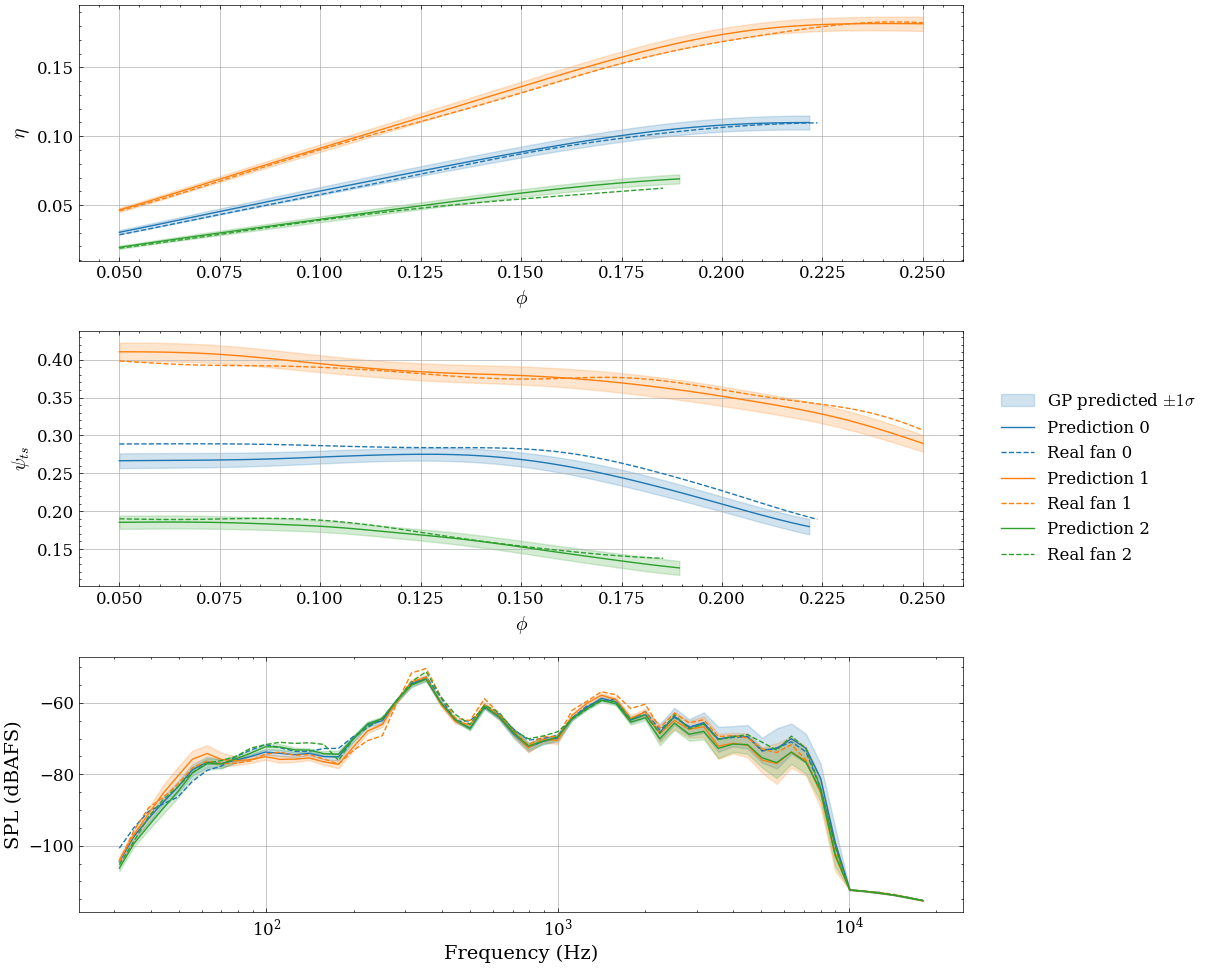

In [81]:
results = pd.read_csv(r'..\optimisation_results_2.csv')
from pca_core import CENTRE_FREQS
import joblib

centre_freqs = CENTRE_FREQS
pca_pressure   = joblib.load("../GPS_PKL/pca_pressure.pkl")
pca_efficiency = joblib.load("../GPS_PKL/pca_efficiency.pkl")
pca_noise      = joblib.load("../GPS_PKL/pca_noise.pkl")
gp_pressure   = joblib.load("../GPS_PKL/gp_pressure.pkl")
gp_efficiency = joblib.load("../GPS_PKL/gp_efficiency.pkl")
gp_noise      = joblib.load("../GPS_PKL/gp_noise.pkl")


n_points = 10
cmap = cm.get_cmap('tab10')  # or 'viridis', 'plasma', 'hsv', etc.
colours = [cmap(i / n_points) for i in range(n_points)]

fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(10, 10), sharex=False)

files = os.listdir('../data/inverse_design_2/')
audio_files = os.listdir('../audio/inverse_design_2/')

pred_phi_maxs = []
pred_psi_maxs = []
pred_eta_maxs = []
pred_oaspls = []

real_psi_maxs = []
real_phi_maxs = []
real_eta_maxs = []
real_oaspls = []

nrmses_psi = []
nrmses_eta = []
nrmses_noise = []

for i, res in results.iterrows():
    # if i == 0:
    #     continue
    
    # if i >= 2 and i<=4:
    #     continue
    
    # if i==5:
    #     i=2
    # elif i==6:
    #     i=3
        
    # Load data
    file_name = files[i]
    filepath = f'../data/inverse_design_2/{file_name}'
    audio_file_name = audio_files[i]
    audio_filepath = f'../audio/inverse_design_2/{audio_file_name}'
    
    # print(filepath, audio_filepath)
    
    phi_common_masked, mean_psi, mean_eta, octave_freqs, a_weighted_octave_bands = get_smoothed_curves_from_files(filepath, audio_filepath)    
    if i==0:
        a_weighted_octave_bands = a_weighted_octave_bands# + difference_db
    
    real_psi_maxs.append(np.max(mean_psi))
    real_phi_maxs.append(axes_crossing(phi_common_masked, mean_psi)[1])
    real_eta_maxs.append(np.max(mean_eta))
    real_oaspls.append(calculate_oaspl(a_weighted_octave_bands))
    
    
    params = res.iloc[:8].to_numpy()

    # Predict curves with design params
    p_curve = pca_pressure.reconstruct(gp_pressure.predict(params)[0])
    e_curve = pca_efficiency.reconstruct(gp_efficiency.predict(params)[0])
    n_curve = pca_noise.reconstruct(gp_noise.predict(params)[0])
    
    
    
    m_psi, s_psi, s_m_psi, s_s_psi, e_m_psi, e_s_psi = gp_pressure.predict(params)
    m_eta, s_eta, s_m_eta, s_s_eta, e_m_eta, e_s_eta = gp_efficiency.predict(params)
    m_noise, s_noise = gp_noise.predict(params)
    
    phi_end_m = gp_pressure.predict(params)[4]
    mask = PHI_COMMON < phi_end_m
    
    p_curve = p_curve[mask]
    e_curve = e_curve[mask]
    PHI_PLOT = PHI_COMMON[mask]
    
    pred_phi_maxs.append(axes_crossing(PHI_COMMON, p_curve)[1])
    pred_psi_maxs.append(np.max(p_curve))
    pred_eta_maxs.append(np.max(e_curve))
    pred_oaspls.append(calculate_oaspl(n_curve))
    
    # NRMSEs
    min_val_psi = np.min([len(p_curve), len(mean_psi)])
    min_val_eta = np.min([len(e_curve), len(mean_eta)])

    rmse_psi = get_nrmse_and_stats_inverse_pred(p_curve[:min_val_psi], mean_psi[:min_val_psi])
    rmse_eta = get_nrmse_and_stats_inverse_pred(e_curve[:min_val_eta], mean_eta[:min_val_eta])
    rmse_noise = get_nrmse_and_stats_inverse_pred(n_curve, a_weighted_octave_bands)

    nrmses_psi.append(rmse_psi)
    nrmses_eta.append(rmse_eta)
    nrmses_noise.append(rmse_noise)

    var       = sum((pca_efficiency.modes[k] * s_eta[k]) ** 2 for k in range(pca_efficiency.n_modes))
    std       = np.sqrt(var)[mask]

    
    if i == 0:
        ax[0].fill_between(PHI_PLOT, pca_efficiency.reconstruct(m_eta)[mask]-std, pca_efficiency.reconstruct(m_eta)[mask]+std, color=colours[i], alpha=0.2, zorder=0, label=f'GP predicted $\pm1\sigma$')
    else:
        ax[0].fill_between(PHI_PLOT, pca_efficiency.reconstruct(m_eta)[mask]-std, pca_efficiency.reconstruct(m_eta)[mask]+std, color=colours[i], alpha=0.2, zorder=0)
    ax[0].plot(PHI_PLOT, e_curve, color=colours[i], label=f'Prediction {i}')
    ax[0].plot(phi_common_masked, mean_eta, color=colours[i], linestyle='--', label=f'Real fan {i}')

    # PSI
    var       = sum((pca_pressure.modes[k] * s_psi[k]) ** 2 for k in range(pca_pressure.n_modes))
    std       = np.sqrt(var)[mask]

    # n_points = 20    
    # m, c, r, p, se = stats.linregress(PHI_PLOT[-n_points:], p_curve[-n_points:])
    # x_crossing = -c/m
    # x = np.linspace(PHI_PLOT[-n_points],x_crossing,50)
    # ax[1].plot(x,m*x+c,color=colours[i])
    # ax[1].scatter(x_crossing,0,marker='o',color=colours[i])
    # ax[1].scatter(0,np.max(p_curve),marker='o',color=colours[i])
    # ax[1].scatter(PHI_PLOT[np.argmax(p_curve)],np.max(p_curve),marker='o',color=colours[i])
    # target_x = input_params["phi_target"].iloc[i]
    # target_y = input_params["psi_target"].iloc[i]
    # ax.scatter(target_x,0,color=colours[i],edgecolors='red')
    # ax.axhline(target_y,linestyle='--',color=colours[i])
    

    ax[1].plot(PHI_PLOT, p_curve, color=colours[i])
    ax[1].plot(phi_common_masked, mean_psi, color=colours[i], linestyle='--')
    ax[1].fill_between(PHI_PLOT, pca_pressure.reconstruct(m_psi)[mask]-std, pca_pressure.reconstruct(m_psi)[mask]+std, color=colours[i], alpha=0.2, zorder=0)
    # m, c, r, p, se = stats.linregress(PHI_PLOT[-n_points:], mean_psi[-n_points:])
    # x_crossing = -c/m
    # x = np.linspace(PHI_PLOT[-n_points],x_crossing,50)
    # ax[1].plot(x,m*x+c,color=colours[i],linestyle='--')
    # ax[1].scatter(x_crossing,0,marker='^',color=colours[i])
    # ax[1].scatter(0,np.max(mean_psi),marker='^',color=colours[i])
    # ax[1].axhline(np.max(mean_psi),xmax=0.05,color=colours[i])
    
    # peak2 = np.max(mean_psi)
    # peak1 = np.max(p_curve)
    # ax[1].annotate('', xy=(ax[1].get_xlim()[0], peak2),
    #             xytext=(ax[1].get_xlim()[0], peak1),
    #         arrowprops=dict(arrowstyle='<->', color='steelblue', lw=1.2,
    #                         shrinkA=0, shrinkB=0))
    # ax[1].text(ax[1].get_xlim()[0] - 0.2, (peak1 + peak2) / 2, f'Δ{peak2-peak1:.2f}',
    #     ha='right', va='center', fontsize=9)
    
    
    
    # Noise
    var       = sum((pca_noise.modes[k] * s_noise[k]) ** 2 for k in range(pca_noise.n_modes))
    std       = np.sqrt(var)

    ax[2].semilogx(centre_freqs, n_curve, color=colours[i])
    ax[2].semilogx(octave_freqs, a_weighted_octave_bands, color=colours[i], linestyle='--')
    ax[2].fill_between(centre_freqs, pca_noise.reconstruct(m_noise)-std, pca_noise.reconstruct(m_noise)+std, color=colours[i], alpha=0.2, zorder=0)
    
    
ax[0].grid()
ax[0].set_xlabel(r'$\phi$')
ax[0].set_ylabel(r'$\eta$')

ax[1].grid()
ax[1].set_xlabel(r'$\phi$')
ax[1].set_ylabel(r'$\psi_{ts}$')

ax[2].grid()
ax[2].set_xlabel('Frequency (Hz)')
ax[2].set_ylabel('SPL (dBAFS)')


# extra_elements = [
#     Line2D([0], [0], marker='o', color='none',
#            markerfacecolor=colours[0], markeredgecolor='none',
#            markersize=8, label=r'Predicted $\phi_{max}$'),
#     Line2D([0], [0], marker='^', color='none',
#            markerfacecolor=colours[0], markeredgecolor='none',
#            markersize=8, label=r'Real $\phi_{max}$'),
# ]
extra_elements = []

existing_handles, existing_labels = ax[0].get_legend_handles_labels()


fig.legend(handles=existing_handles +extra_elements, bbox_to_anchor=(1.01, 0.6), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.savefig(r'C:\Users\angus\OneDrive\Documents\Cambridge\Year 4\Project\diagrams for final report\predicted_fan_curves_with_real_intro.svg', bbox_inches='tight')
plt.show()

In [82]:
design_points = pd.read_csv("../fan_inverse_design_parameters.csv")
design_psi_maxs = design_points["psi_target"].to_numpy()
design_phi_maxs = design_points["phi_target"].to_numpy()

In [83]:
dict_total = {
    "design_psi_maxs": design_psi_maxs,
    "pred_psi_maxs": pred_psi_maxs,
    "real_psi_maxs": real_psi_maxs,
    "design_phi_maxs": design_phi_maxs,
    "pred_phi_maxs": pred_phi_maxs,
    "real_phi_maxs": real_phi_maxs,
    "pred_eta_maxs": pred_eta_maxs,
    "real_eta_maxs": real_eta_maxs,
    "pred_oaspls": pred_oaspls,
    "real_oaspls": real_oaspls
    
}

df_results = pd.DataFrame(dict_total)

In [84]:
df_results.head()

,design_psi_maxs,pred_psi_maxs,real_psi_maxs,design_phi_maxs,pred_phi_maxs,real_phi_maxs,pred_eta_maxs,real_eta_maxs,pred_oaspls,real_oaspls
0,0.344100,0.275172,0.288986,0.377700,0.374788,0.341750,0.109928,0.109685,-47.142902,-46.765135
1,0.475370,0.410443,0.398349,0.563318,0.465073,0.545756,0.181743,0.182903,-46.849446,-45.078534
2,0.236762,0.185680,0.190539,0.369836,0.425875,0.470434,0.068998,0.062291,-47.422238,-46.263279


In [85]:
errors = df_results[["pred_psi_maxs", "real_psi_maxs"]].apply(lambda row: abs(row["pred_psi_maxs"] - row["real_psi_maxs"])/row["real_psi_maxs"], axis=1)
print(np.mean(errors))

0.03455409642811228


In [86]:
errors = df_results[["pred_eta_maxs", "real_eta_maxs"]].apply(lambda row: abs(row["pred_eta_maxs"] - row["real_eta_maxs"])/row["real_eta_maxs"], axis=1)
print(np.mean(errors))

0.03874328973911519


In [87]:
errors = df_results[["pred_phi_maxs", "real_phi_maxs"]].apply(lambda row: abs(row["pred_phi_maxs"] - row["real_phi_maxs"])/row["real_phi_maxs"], axis=1)
print(np.mean(errors))

0.11307647943499598


In [88]:
errors = df_results[["pred_oaspls", "real_oaspls"]].apply(lambda row: abs(row["pred_oaspls"] - row["real_oaspls"])/row["real_oaspls"], axis=1)
print(np.mean(errors))

-0.024138120038097288


In [89]:
print(nrmses_psi)

[np.float64(17.363582975874436), np.float64(11.209274655995799), np.float64(10.295306235122476)]


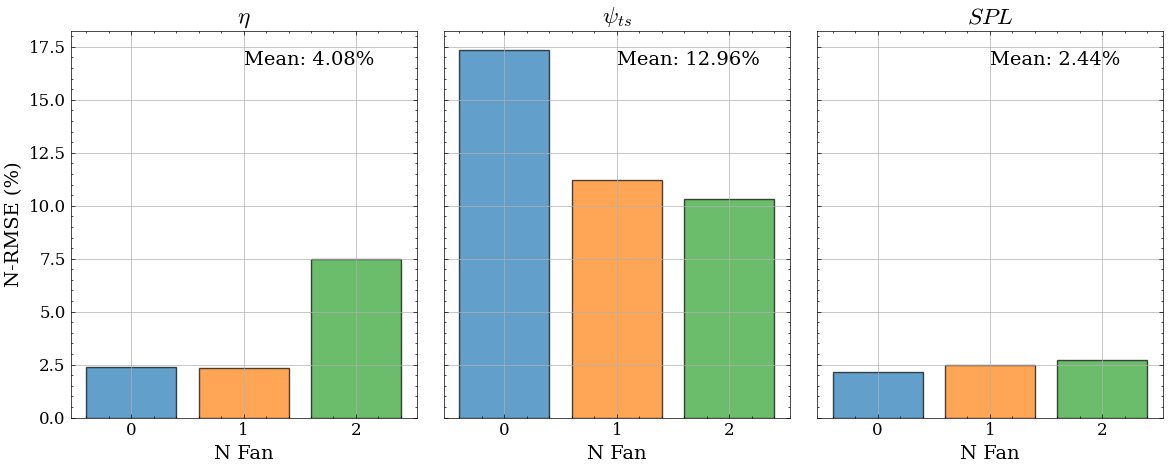

In [90]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12, 5), sharey=True)

bin_width = 0.1
bins = np.arange(0, 5 + bin_width, bin_width)
excellent_val = 1
fair_val = 5
n_stds = 3

# ETA
rmse_per_run_eta, mean_rmse_eta, median_rmse_eta = nrmses_eta, np.mean(nrmses_eta), np.median(nrmses_eta)
bars = ax[0].bar(range(len(rmse_per_run_eta)), rmse_per_run_eta, 
        width=0.8,           # bar width (default 0.8, in data units)
        edgecolor='black',   # border colour
        linewidth=1.0,       # border thickness
        color=colours[:3],        # fill colour
        alpha=0.7,           # transparency
        )
       
# ax[0].axvline(mean_rmse_eta+n_stds*np.std(rmse_per_run_eta), color='red', alpha=0.7, linestyle='--')
ax[0].grid()
ax[0].set_ylabel('N-RMSE (%)')
ax[0].set_xlabel('N Fan')
ax[0].set_title("$\eta$")
# ax[0].set_xlim(0,6)
# ax[0].set_ylim(0,25)
ax[0].text(0.5, 0.95, f'Mean: {mean_rmse_eta:.2f}%',
        transform=ax[0].transAxes,  # 0-1 relative to axes
        ha='left', va='top')
ax[0].set_xticks(range(len(rmse_per_run_eta)))

# # Color bars based on their index (position)
# for i, bar in enumerate(bars):
#     bar.set_alpha(0.7)
#     if bar.get_height() < excellent_val:
#         bar.set_facecolor("#23a508")
#     elif bar.get_height() < fair_val:
#         bar.set_facecolor("#e4e009")
#     else:
#         bar.set_facecolor("#c40808")

# PSI
rmse_per_run_psi, mean_rmse_psi, median_rmse_psi = nrmses_psi, np.mean(nrmses_psi), np.median(nrmses_psi)

bars = ax[1].bar(range(len(rmse_per_run_psi)), rmse_per_run_psi,
                 width=0.8,           # bar width (default 0.8, in data units)
        edgecolor='black',   # border colour
        linewidth=1.0,       # border thickness
        color=colours[:3],        # fill colour
        alpha=0.7,           # transparency
        )
# ax[1].axvline(mean_rmse_psi+n_stds*np.std(rmse_per_run_psi), color='red', alpha=0.7, linestyle='--')
ax[1].grid()
ax[1].set_xlabel('N Fan')
# ax[1].set_ylabel('N-RMSE (%)')
ax[1].set_title("$\psi_{ts}$")
# ax[1].set_xlim(0,6)
# ax[1].set_ylim(0,25)
ax[1].text(0.5, 0.95, f'Mean: {mean_rmse_psi:.2f}%',
        transform=ax[1].transAxes,  # 0-1 relative to axes
        ha='left', va='top')
ax[1].set_xticks(range(len(rmse_per_run_psi)))

# # Color bars based on their index (position)
# for i, bar in enumerate(bars):
#     bar.set_alpha(0.7)
#     if bar.get_height() < excellent_val:
#         bar.set_facecolor("#23a508")
#     elif bar.get_height() < fair_val:
#         bar.set_facecolor("#e4e009")
#     else:
#         bar.set_facecolor("#c40808")

# SPL     
rmse_per_run, mean_rmse, median_rmse = nrmses_noise, np.mean(nrmses_noise), np.median(nrmses_noise)
bars = ax[2].bar(range(len(rmse_per_run)), rmse_per_run,
                 width=0.8,           # bar width (default 0.8, in data units)
        edgecolor='black',   # border colour
        linewidth=1.0,       # border thickness
        color=colours[:3],        # fill colour
        alpha=0.7,           # transparency
        )
# ax[2].axvline(mean_rmse+n_stds*np.std(rmse_per_run), color='red', alpha=0.7, linestyle='--')
ax[2].grid()
# ax[2].set_ylabel('N-RMSE (%)')
ax[2].set_xlabel('N Fan')
# ax[2].set_xlim(0,6)
# ax[2].set_ylim(0,25)
ax[2].set_title("$SPL$")
ax[2].text(0.5, 0.95, f'Mean: {mean_rmse:.2f}%',
        transform=ax[2].transAxes,  # 0-1 relative to axes
        ha='left', va='top')
ax[2].set_xticks(range(len(rmse_per_run)))

# # Color bars based on their index (position)
# for i, bar in enumerate(bars):
#     bar.set_alpha(0.7)
#     if bar.get_height() < excellent_val:
#         bar.set_facecolor("#23a508")
#     elif bar.get_height() < fair_val:
#         bar.set_facecolor("#e4e009")
#     else:
#         bar.set_facecolor("#c40808")

# Legend
# green_patch  = mpatches.Patch(color="#23a508", alpha = 0.7,  label=f'N-RMSE<{excellent_val}% (Excellent)')
# yellow_patch = mpatches.Patch(color="#e4e009", alpha = 0.7, label=f'{excellent_val}%<N-RMSE<{fair_val}% (Fair)')
# red_patch    = mpatches.Patch(color="#c40808", alpha = 0.7,    label=f'N-RMSE>{fair_val}% (Poor)')
# threshold_line = mlines.Line2D([], [], color='red', alpha=0.7, linestyle='--', label=f'$\mu+{n_stds}\sigma$')


# fig.legend(handles=[green_patch, yellow_patch, red_patch, threshold_line], bbox_to_anchor=(1.01, 0.6), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.savefig(r'C:\Users\angus\OneDrive\Documents\Cambridge\Year 4\Project\diagrams for final report\inverse_design_RMSE.svg', bbox_inches='tight')
plt.show()

# Presentation Extras

In [91]:
ETA_PCA = pca_efficiency
PSI_PCA = pca_pressure
NOISE_PCA = pca_noise

In [92]:
print(len([run["eta"] for run in ETA_PCA.runs]))

84


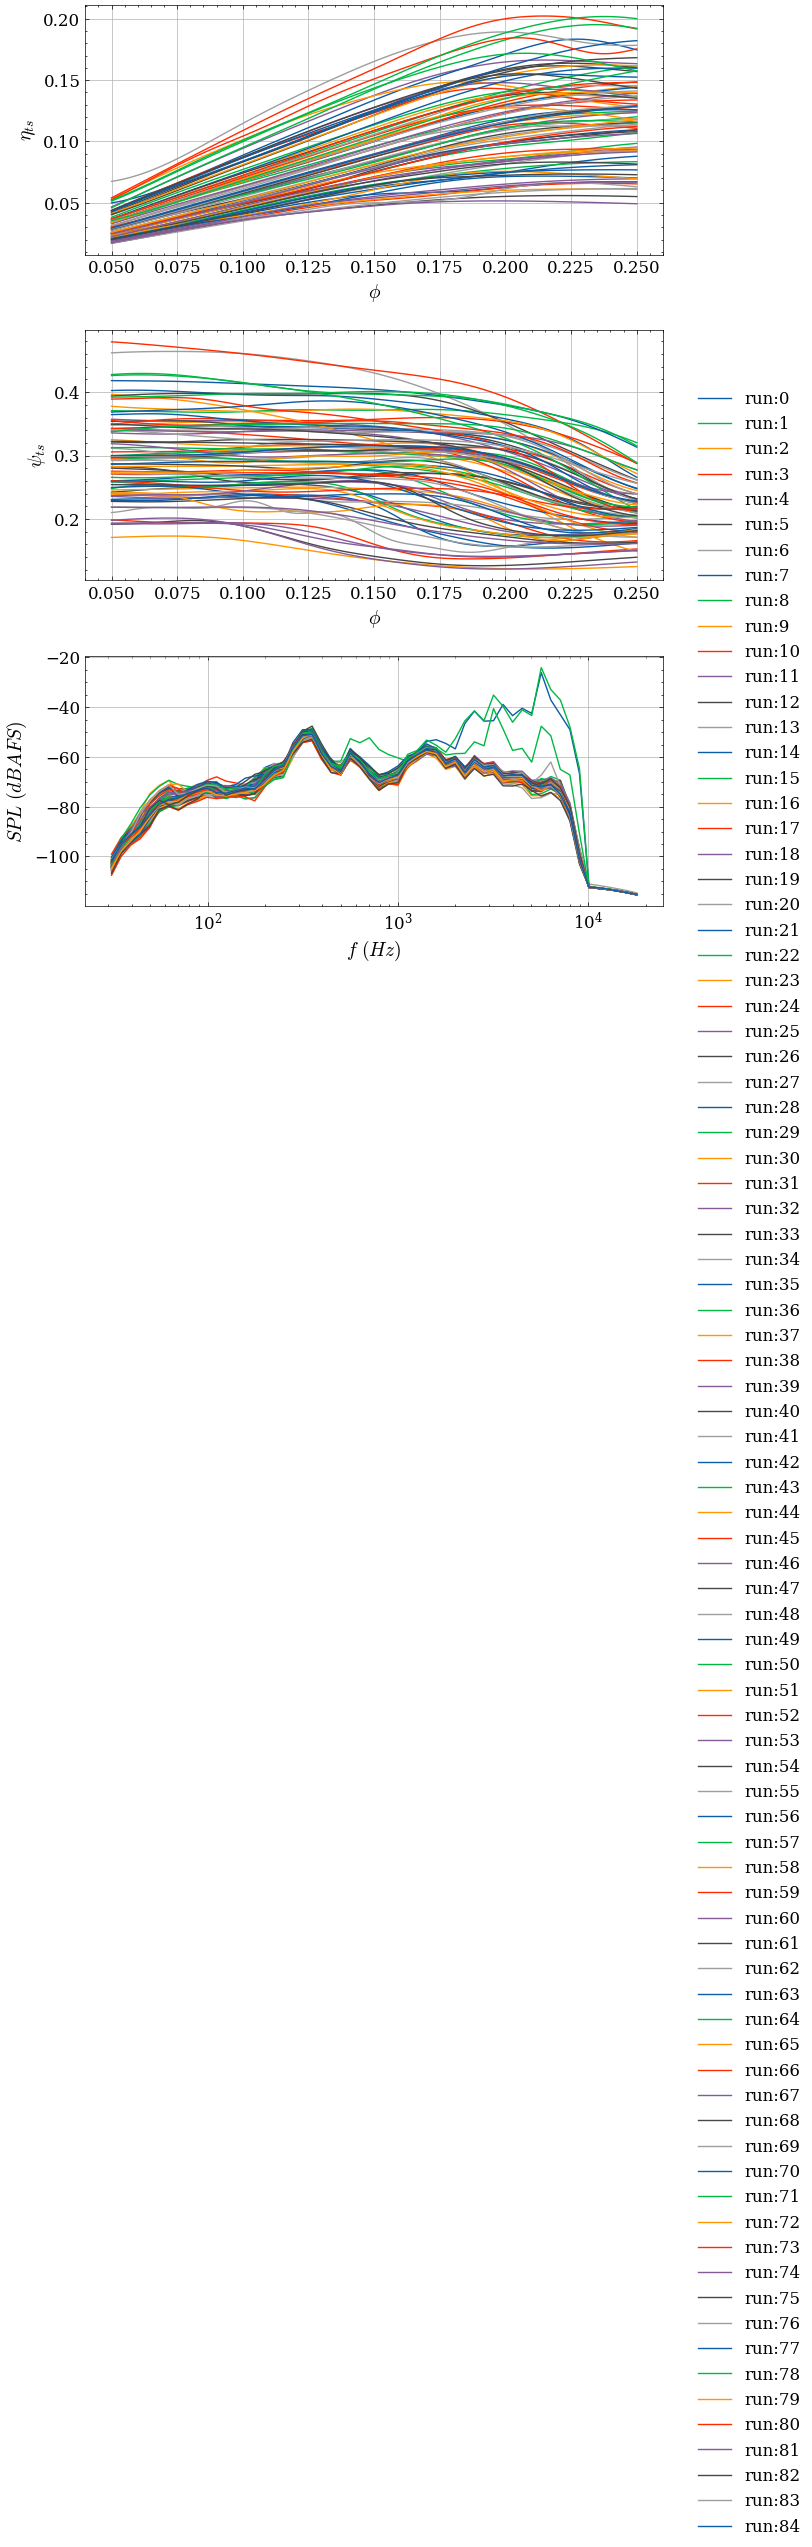

In [93]:
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(7, 10))
# index = 79
for index in range(85):
    psi, phi_end, eta = get_psi_eta_gp_with_end(index=index)

    # ETA

    ax[0].plot(PHI_COMMON, eta, label=f"run:{index}")
    ax[0].grid()
    ax[0].set_xlabel('$\phi$')
    ax[0].set_ylabel('$\eta_{ts}$')
    ax[0].set_xlim(0.04, 0.26)

    # PSI

    ax[1].plot(PHI_COMMON, psi,)

    ax[1].grid()
    ax[1].set_xlabel('$\phi$')
    ax[1].set_ylabel('$\psi_{ts}$')
    ax[1].set_xlim(0.04, 0.26)

    # Audio

    centre_freqs, band_levels = sixth_octave_bands_from_index(index)

    ax[2].semilogx(centre_freqs, band_levels)    
    # ax[2].set_xlim(100, 500)
    ax[2].grid()
    ax[2].set_xlabel('$f \ (Hz)$')
    ax[2].set_ylabel('$SPL \ (dBAFS)$')


fig.legend(bbox_to_anchor=(1.01, 0.6), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.savefig(r'C:\Users\angus\OneDrive\Documents\Cambridge\Year 4\Project\final_presentation_diagrams\all_data_legend.svg', bbox_inches='tight')
plt.show()

In [94]:
# %matplotlib widget
# import matplotlib.pyplot as plt
# import matplotlib.animation as animation
# import numpy as np

# # ── Config ────────────────────────────────────────────────────────────────────
# NUM_RUNS = 85
# COMPLETED_ALPHA = 0.15
# COMPLETED_LW = 0.8
# ACTIVE_LW = 1.2
# INTERVAL_MS = 1
# POINT_STEP = 1

# # ── Pre-load all data ─────────────────────────────────────────────────────────
# all_psi, all_phi_end, all_eta, all_freqs, all_levels = [], [], [], [], []

# for index in range(NUM_RUNS):
#     psi, phi_end, eta = get_psi_eta_gp_with_end(index=index)
#     centre_freqs, band_levels = sixth_octave_bands_from_index(index)
#     all_psi.append(psi)
#     all_phi_end.append(phi_end)
#     all_eta.append(eta)
#     all_freqs.append(centre_freqs)
#     all_levels.append(band_levels)

# # ── Infer lengths (eta/psi share PHI_COMMON, audio may differ) ───────────────
# N_curves = len(PHI_COMMON)
# N_audio  = len(all_freqs[0])

# # Use the longer of the two for frame pacing; audio will just finish early
# N = max(N_curves, N_audio)

# # ── Pre-compute axis limits ───────────────────────────────────────────────────
# eta_min   = min(e.min() for e in all_eta)
# eta_max   = max(e.max() for e in all_eta)
# psi_min   = min(p.min() for p in all_psi)
# psi_max   = max(p.max() for p in all_psi)
# lvl_min   = min(l.min() for l in all_levels)
# lvl_max   = max(l.max() for l in all_levels)
# freq_min  = min(f.min() for f in all_freqs)
# freq_max  = max(f.max() for f in all_freqs)

# def pad(lo, hi, frac=0.05):
#     p = (hi - lo) * frac
#     return lo - p, hi + p

# # ── Figure setup ──────────────────────────────────────────────────────────────
# fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(7, 10))
# fig.subplots_adjust(hspace=0.45)

# # ── ax[0]: eta ────────────────────────────────────────────────────────────────
# ax[0].set_xlabel(r'$\phi$')
# ax[0].set_ylabel(r'$\eta_{ts}$')
# ax[0].set_xlim(0.04, 0.26)
# ax[0].set_ylim(*pad(eta_min, eta_max))
# ax[0].grid()

# # ── ax[1]: psi ────────────────────────────────────────────────────────────────
# ax[1].set_xlabel(r'$\phi$')
# ax[1].set_ylabel(r'$\psi_{ts}$')
# ax[1].set_xlim(0.04, 0.26)
# ax[1].set_ylim(*pad(psi_min, psi_max))
# ax[1].grid()

# # ── ax[2]: audio ─────────────────────────────────────────────────────────────
# ax[2].set_xlabel(r'$f \ (Hz)$')
# ax[2].set_ylabel(r'$SPL \ (dBAFS)$')
# ax[2].set_xlim(freq_min * 0.9, freq_max * 1.1)
# ax[2].set_ylim(*pad(lvl_min, lvl_max))
# ax[2].grid()

# # Title / run counter
# title = fig.suptitle("Run 1 / 85  |  [░░░░░░░░░░░░░░░░░░░░] 0%", fontsize=11, y=1.01)

# # ── Active lines (reused each run) ────────────────────────────────────────────
# line_eta,  = ax[0].plot([], [], color='k', linewidth=ACTIVE_LW)
# line_psi,  = ax[1].plot([], [], color='k', linewidth=ACTIVE_LW)
# line_audio,= ax[2].semilogx([], [], color='k', linewidth=ACTIVE_LW)

# active_lines = [line_eta, line_psi, line_audio]
# completed_lines = []   # grows as runs finish

# # ── Frame math ────────────────────────────────────────────────────────────────
# frames_per_run = (N // POINT_STEP) + 1   # 1 reset frame + drawing frames
# total_frames   = NUM_RUNS * frames_per_run

# def get_run_and_step(frame):
#     run  = frame // frames_per_run
#     step = frame  % frames_per_run
#     return run, step

# # ── Update ────────────────────────────────────────────────────────────────────
# def update(frame):
#     run, step = get_run_and_step(frame)
#     point = step * POINT_STEP

#     if step == 0:
#         # Freeze active lines as faded completed lines
#         for line in active_lines:
#             xd, yd = line.get_xdata(), line.get_ydata()
#             if len(xd) > 0:
#                 # semilogx for audio panel, regular plot for others
#                 if line.axes is ax[2]:
#                     faded, = ax[2].semilogx(
#                         xd, yd, color='k',
#                         alpha=COMPLETED_ALPHA, linewidth=COMPLETED_LW, zorder=1
#                     )
#                 else:
#                     faded, = line.axes.plot(
#                         xd, yd, color='k',
#                         alpha=COMPLETED_ALPHA, linewidth=COMPLETED_LW, zorder=1
#                     )
#                 completed_lines.append(faded)

#         # Clear active lines
#         for line in active_lines:
#             line.set_data([], [])

#         title.set_text(f"Run {run + 1} / {NUM_RUNS}  |  Starting...")

#     else:
#         # eta and psi: index into PHI_COMMON
#         end_c = min(point, N_curves)
#         line_eta.set_data(PHI_COMMON[:end_c], all_eta[run][:end_c])
#         line_psi.set_data(PHI_COMMON[:end_c], all_psi[run][:end_c])

#         # audio: shorter array — clamp so we don't overshoot
#         end_a = min(point, N_audio)
#         line_audio.set_data(all_freqs[run][:end_a], all_levels[run][:end_a])

#         # Progress bar
#         progress = point / N
#         bar_len  = 20
#         filled   = int(progress * bar_len)
#         bar      = "█" * filled + "░" * (bar_len - filled)
#         pct      = int(progress * 100)
#         title.set_text(f"Run {run + 1} / {NUM_RUNS}  |  [{bar}] {pct}%")

#     if frame == total_frames - 1:
#         title.set_text(f"Done  |  All {NUM_RUNS} runs complete")
#         ani.event_source.stop()

#     return active_lines + completed_lines + [title]

# # ── Run ───────────────────────────────────────────────────────────────────────
# ani = animation.FuncAnimation(
#     fig,
#     update,
#     frames=total_frames,
#     interval=INTERVAL_MS,
#     blit=True,
#     repeat=False,
# )

# plt.tight_layout()
# plt.show()

# # ani.save("runs.gif", writer="pillow", fps=30)
# # ani.save("runs.mp4", writer="ffmpeg", fps=30)

In [95]:
plt.close("all")